# **QM640 Data Analytics Capstone Project**

## **Machine Learning-Based Forecasting of Urban Air Quality Using Environmental and Meteorological Data**

**Student:** Vinita R. Shetty

**Course:** QM640 Data Analytics Capstone

**Mentor:** Karthik Umesh

**Dataset:** Beijing Multi-Site Air Quality Dataset (UCI Machine Learning Repository)

# **Problem Statement**

Urban air pollution poses significant environmental and public health challenges. Accurate short-term forecasting of PM2.5 concentrations can support air quality monitoring, early-warning systems, and environmental decision-making. This study aims to develop and compare multiple machine learning models to forecast PM2.5 concentrations one hour ahead using air pollutant, meteorological, temporal, and location-related information available at the current hour from the Beijing Multi-Site Air Quality Dataset.

# **Data Dictionary**

| Variable            | Description                                                                 |
| ------------------- | --------------------------------------------------------------------------- |
| **PM2.5_next_hour** | **Target variable representing PM2.5 concentration one hour ahead (µg/m³)** |
| PM2.5               | Current-hour PM2.5 concentration (µg/m³)                                    |
| PM10                | Current-hour particulate matter ≤10 µm concentration (µg/m³)                |
| SO₂                 | Current-hour sulfur dioxide concentration                                   |
| NO₂                 | Current-hour nitrogen dioxide concentration                                 |
| CO                  | Current-hour carbon monoxide concentration                                  |
| O₃                  | Current-hour ozone concentration                                            |
| TEMP                | Current-hour temperature (°C)                                               |
| PRES                | Current-hour atmospheric pressure (hPa)                                     |
| DEWP                | Current-hour dew point temperature (°C)                                     |
| RAIN                | Current-hour rainfall (mm)                                                  |
| WSPM                | Current-hour wind speed (m/s)                                               |
| wd                  | Wind direction                                                              |
| station             | Monitoring station                                                          |
| year                | Year of observation                                                         |
| month               | Month                                                                       |
| day                 | Day                                                                         |
| hour                | Hour                                                                        |


# **Installation of Required Packages**

In [1]:
# ==========================================
# Install Required Packages
# ==========================================

!pip install xgboost lightgbm catboost shap -q   # Installs four ML libraries quietly (-q suppresses logs)

print("Required packages installed successfully!")  # Confirmation message


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.9 MB/s eta 0:00:00
Required packages installed successfully!


### **Note:**
*  The required external Python packages were successfully installed to support the machine learning modelling and model interpretation stages of the analysis.

# **1. Import Libraries**

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd                 # Pandas: data handling and DataFrames
import numpy as np                  # NumPy: numerical and mathematical operations

import matplotlib.pyplot as plt     # Matplotlib: plots and charts
import seaborn as sns               # Seaborn: statistical data visualization

# Machine Learning Models
from sklearn.linear_model import LinearRegression           # Linear Regression baseline
from sklearn.tree import DecisionTreeRegressor              # Decision Tree Regressor
from sklearn.ensemble import (                              # Ensemble models
    RandomForestRegressor,                                  # Random Forest
    GradientBoostingRegressor,                              # Gradient Boosting
    AdaBoostRegressor                                       # AdaBoost
)

# Time-Series Validation
from sklearn.model_selection import TimeSeriesSplit         # Chronological CV splitter

# Model Evaluation Metrics
from sklearn.metrics import (                               # Performance metrics
    mean_absolute_error,            # MAE: average absolute prediction error
    mean_squared_error,             # MSE: squared prediction error
    r2_score                        # R²: proportion of variance explained
)

# Advanced Machine Learning Models
from xgboost import XGBRegressor                            # XGBoost Regressor
from lightgbm import LGBMRegressor                          # LightGBM Regressor
from catboost import CatBoostRegressor                      # CatBoost Regressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")                           # Suppress warnings for clean output

# Display settings
pd.set_option("display.max_columns", None)                  # Show all columns in DataFrames

print("Libraries imported successfully!")                   # Confirmation message


Libraries imported successfully!


### **Interpretation:**

* All the required Python libraries for data manipulation, visualization, machine learning, and model evaluation were successfully imported. This confirms that the computational environment was properly configured before proceeding with data loading, preprocessing, exploratory data analysis, and predictive modeling.

## **1.1 Mount Google Drive**

In [3]:
from google.colab import drive        # Import the Colab Drive module, which lets you mount Google Drive
drive.mount('/content/drive')         # Mount your Google Drive at the folder path '/content/drive'


Mounted at /content/drive


### **Interpretation:**

* Google Drive was successfully mounted, enabling access to the project dataset and associated files stored in the user's Drive. This ensured that the data could be loaded directly into the Colab environment for subsequent preprocessing, analysis, and model development.

# **2. Data Loading and Integration**

* The dataset consists of **hourly air quality and meteorological observations** collected from **12 monitoring stations in Beijing**.

* The individual station datasets were combined into a single DataFrame to create an integrated dataset for subsequent **data preprocessing, exploratory analysis, and one-hour-ahead PM2.5 forecasting**.


## **2.1 Locate the Dataset**
* The project directory was inspected to verify that the required dataset files were available in Google Drive before loading and integrating the data.

In [4]:
import os                                      # Import Python’s built-in OS module for file and directory operations

base_path = "/content/drive/MyDrive/QM640_Air_Quality_Capstone"
# Define the base directory path where your project files are stored in Google Drive

for root, dirs, files in os.walk(base_path):   # Recursively walk through the directory tree starting at base_path
    for file in files:                         # Loop through each file found in the current folder
        print(os.path.join(root, file))        # Print the full file path by joining folder path (root) and file name


/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Aotizhongxin_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Changping_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Dingling_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Dongsi_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Guanyuan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Gucheng_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Huairou_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Nongzhanguan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Shunyi_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Tiantan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quali

### **Interpretation:**

* The dataset consists of **12 CSV files**, each representing hourly air quality and meteorological observations from a different monitoring station in Beijing.

* The files collectively cover the period from **1 March 2013 to 28 February 2017** and contain measurements of major air pollutants and meteorological variables.

* Combining data from all 12 monitoring stations provides a comprehensive multi-location dataset covering different environmental conditions across Beijing.

* This integrated dataset supports the development and evaluation of machine learning models for **one-hour-ahead PM2.5 forecasting**.


## **2.2 Load and Combine All Air Quality Datasets**

In [5]:
# ==========================================
# Load and Combine All Air Quality Datasets
# ==========================================

import os                                   # OS module for file and directory operations
import glob                                 # Glob module for pattern matching file paths
import pandas as pd                         # Pandas for data handling and analysis

# Folder containing all CSV files
folder_path = "/content/drive/MyDrive/QM640_Air_Quality_Capstone/data"
# Define the path to the folder where all your CSV datasets are stored

# Find all CSV files
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
# Use glob to search for all files ending with .csv inside the folder

print(f"Number of CSV files found: {len(csv_files)}")
# Print how many CSV files were found in the folder

# Read and combine all files
df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)
# Read each CSV file into a DataFrame and combine them into one large DataFrame
# ignore_index=True resets the row index so it runs continuously across all files

print("Dataset loaded successfully!")
# Confirmation message once the dataset is combined

# Display first five rows
df.head()
# Show the first 5 rows of the combined dataset to verify it loaded correctly


Number of CSV files found: 12
Dataset loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### **Interpretation:**

* A total of **12 CSV files**, representing different Beijing air quality monitoring stations, were successfully identified and combined into a single dataset.

* The combined dataset was loaded successfully, and the preview confirms that observations from the station-level files are available for subsequent analysis.

* The dataset contains **temporal variables, air pollutant concentrations, meteorological variables, and monitoring station information**.

* The current-hour PM2.5 measurements and other available predictor variables will subsequently be used to develop machine learning models for **one-hour-ahead PM2.5 forecasting**.


 ## **2.3 Initial Data Inspection**
* The first and last five records are displayed to verify that the datasets have been merged correctly and to obtain an initial understanding of the dataset structure.

### **2.3.1 First Five Records of the Dataset**

In [6]:
print("First Five Records")     # Print a header message to indicate what is being displayed

df.head()                       # Show the first 5 rows of the DataFrame 'df'
                                # Useful for quickly checking that the dataset loaded correctly
                                # and to preview the structure, column names, and sample values

First Five Records


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### **Interpretation:**

* The first five records provide an initial overview of the **integrated air quality dataset**.

* Each row represents an **hourly observation** containing temporal information, pollutant concentrations, meteorological variables, and the monitoring station name.

* The preview shows that the dataset is organized in a structured tabular format with the expected variables available for subsequent analysis.

* The available variables provide the information required for **data preprocessing, exploratory data analysis, and the subsequent development of machine learning models for one-hour-ahead PM2.5 forecasting**.

### **2.3.2 Last Five Records of the Dataset**

In [7]:
print("Last Five Records")     # Print a header message to indicate what is being displayed

df.tail()                      # Show the last 5 rows of the DataFrame 'df'
                               # Useful for checking the dataset’s ending rows
                               # Helps confirm that all files were combined correctly
                               # and lets you preview how the dataset concludes


Last Five Records


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong
420767,35064,2017,2,28,23,13.0,19.0,4.0,38.0,600.0,49.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Wanshouxigong


### **Interpretation:**

* The last five records provide a view of the final observations in the integrated dataset and show data from the **Wanshouxigong monitoring station**.

* The records maintain the same structure as the initial observations, containing temporal information, air pollutant concentrations, meteorological variables, and the monitoring station identifier.

* The final records correspond to **28 February 2017**, which is consistent with the stated end date of the study period.

* Together with the first-record inspection, this provides an initial verification of the structure and temporal coverage of the combined dataset. Further checks on dataset dimensions, monitoring stations, missing values, duplicates, and data types are performed during subsequent data inspection and preprocessing.

* The integrated dataset will subsequently be prepared for **one-hour-ahead PM2.5 forecasting**.

# **3. Dataset Overview**
* This section examines the overall dimensions, variables, data types, descriptive statistics, and missing values before data preprocessing.

## **3.1 Dataset Dimensions**

In [8]:
df.shape                          # Returns a tuple with (number of rows, number of columns)
                                  # First value = total records in the dataset
                                  # Second value = total features/columns in the dataset
                                  # Useful for quickly checking dataset size and structure


(420768, 18)

### **Interpretation:**

* The integrated dataset contains **420,768 observations and 18 variables**, confirming that a substantial volume of hourly air quality and meteorological data is available for analysis.

* The 18 variables include **temporal information, air pollutant concentrations, meteorological parameters, wind direction, and the monitoring station identifier**.

* The large number of observations provides sufficient data for **exploratory data analysis, feature engineering, model development, and time-based model evaluation**.

* The available variables provide a comprehensive set of information for developing machine learning models for **one-hour-ahead PM2.5 forecasting**.

## **3.2 Data Types**

In [9]:
df.info()
# Displays a concise summary of the DataFrame 'df'
# Shows:
#   - Index range (row count)
#   - Column names
#   - Number of non-null (non-missing) values per column
#   - Data types of each column (int, float, object, etc.)
#   - Memory usage of the DataFrame
# Useful for quickly checking dataset structure, column types, and missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


### **Interpretation:**

* The dataset contains **420,768 observations and 18 variables**, consisting of **5 integer variables, 11 floating-point variables, and 2 object-type variables**.

* The integer variables primarily represent temporal and record-related information, while the floating-point variables contain air pollutant concentrations and meteorological measurements.

* The two object-type variables are **wind direction (`wd`)** and **monitoring station (`station`)**, which are categorical variables and will require appropriate encoding before machine learning model development.

* Several variables, including **PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, and WSPM**, contain missing values. These will be examined and handled during the data preprocessing stage.

* The dataset uses approximately **57.8 MB of memory**, indicating that the complete integrated dataset can be handled efficiently within the current computational environment.

* The combination of pollutant, meteorological, temporal, and categorical information provides the predictor information required for subsequent exploratory analysis, feature engineering, and **one-hour-ahead PM2.5 forecasting**.

## **3.3 Variable Names**

In [10]:
df.columns                       # Returns all column names in the DataFrame
                                 # Output is an Index object listing features/variables
                                 # Useful for quickly checking dataset structure


Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

### **Interpretation:**

* The dataset contains **18 columns**, including the record identifier (**No**), temporal variables (**year**, **month**, **day**, and **hour**), air pollutant variables (**PM2.5**, **PM10**, **SO2**, **NO2**, **CO**, and **O3**), meteorological variables (**TEMP**, **PRES**, **DEWP**, **RAIN**, and **WSPM**), wind direction (**wd**), and the monitoring station identifier (**station**).

* The column names are clearly defined and consistently labelled, facilitating systematic data preprocessing, exploratory data analysis, feature engineering, and machine learning model development.

* The dataset contains both **numerical and categorical variables**, providing information on pollutant levels, meteorological conditions, time, and monitoring location that can be examined as potential predictors of **one-hour-ahead PM2.5 concentrations**.

* The `No` column functions as a **record identifier** and does not represent an environmental, meteorological, temporal, or location-related predictor. Therefore, it is excluded during the feature selection stage before machine learning model development.

## **3.4 Summary Statistics**

In [11]:
df.describe().T                 # Generates summary statistics for numeric columns
                                # Includes count, mean, std, min, 25%, 50%, 75%, max
                                # '.T' transposes the table so each column’s stats are listed vertically
                                # Easier to scan values feature by feature


,count,mean,std,min,25%,50%,75%,max
No,420768.0,17532.500000,10122.116943,1.0000,8766.75,17532.5,26298.25,35064.0
year,420768.0,2014.662560,1.177198,2013.0000,2014.00,2015.0,2016.00,2017.0
month,420768.0,6.522930,3.448707,1.0000,4.00,7.0,10.00,12.0
day,420768.0,15.729637,8.800102,1.0000,8.00,16.0,23.00,31.0
hour,420768.0,11.500000,6.922195,0.0000,5.75,11.5,17.25,23.0
PM2.5,412029.0,79.793428,80.822391,2.0000,20.00,55.0,111.00,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.00,82.0,145.00,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.00,7.0,20.00,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.00,43.0,71.00,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.00,900.0,1500.00,10000.0


### **Interpretation:**

#### **PM2.5**
* The average **PM2.5** concentration is **79.79 µg/m³**, with values ranging from **2** to **999 µg/m³**, indicating substantial variation in fine particulate matter concentrations across the observations.

#### **PM10**
* **PM10** concentrations have a mean of **104.60 µg/m³** and range from **2** to **999 µg/m³**, indicating considerable variability throughout the study period.

#### **SO2**
* **SO2** concentrations remain relatively low on average (**15.83 µg/m³**), although higher values indicate occasional elevated observations.

#### **NO2**
* **NO2** has an average concentration of **50.64 µg/m³**, with values ranging from **1.03** to **290 µg/m³**, demonstrating substantial variability across the dataset.

#### **CO**
* **CO** concentrations range from **100** to **10,000**, with a mean of **1230.77**, indicating noticeable variation in carbon monoxide levels.

#### **O3**
* **O3** concentrations vary considerably, with values ranging from **0.21** to **1071 µg/m³**, reflecting changing atmospheric conditions over time.

#### **TEMP**
* **Temperature (TEMP)** ranges from **−19.9°C** to **41.6°C**, demonstrating the wide seasonal variation captured during the study period.

#### **PRES**
* **Atmospheric pressure (PRES)** has a mean of **1010.75 hPa** with relatively low variation, indicating generally stable atmospheric pressure conditions.

#### **DEWP**
* **Dew point (DEWP)** ranges from **−43.4°C** to **29.1°C**, indicating substantial variation in atmospheric moisture conditions.

#### **RAIN**
* **Rainfall (RAIN)** is absent in most observations, as indicated by both the median and the 75th percentile being **0 mm**, while occasional rainfall events are reflected by the maximum value of **72.5 mm**.

#### **WSPM**
* **Wind speed (WSPM)** has an average value of **1.73 m/s**, with observations ranging from **0** to **13.2 m/s**, indicating varying wind conditions throughout the study period.

#### **Overall Observation**
* The descriptive statistics indicate substantial variability in both air pollutant concentrations and meteorological conditions across the dataset.

* Several variables exhibit relatively large maximum values compared with their upper quartiles, suggesting the presence of potential extreme observations that will be further examined during data preprocessing.

* The diversity of pollutant, meteorological, and temporal information provides a strong foundation for developing machine learning models for **one-hour-ahead PM2.5 forecasting**.

## **3.5 Missing Value Summary**

In [12]:
df.isnull().sum()              # Counts missing (null) values in each column
                               # .isnull() creates True/False mask (True = missing)
                               # .sum() adds up True values per column
                               # Result: number of nulls per column


,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


### **Interpretation:**

#### **Overall Missing Values**

* The dataset contains missing values in several air pollutant and meteorological variables, while the temporal variables (**No, year, month, day,** and **hour**) and the **station** identifier contain no missing values.

#### **Air Pollutant Variables**

* Missing values are observed in **PM2.5 (8,739)**, **PM10 (6,449)**, **SO2 (9,021)**, **NO2 (12,116)**, **CO (20,701)**, and **O3 (13,277)**.

* Among the air pollutant variables, **CO** has the highest number of missing observations, followed by **O3** and **NO2**.

#### **Meteorological Variables**

* The meteorological variables contain comparatively fewer missing values, including **TEMP (398)**, **PRES (393)**, **DEWP (403)**, **RAIN (390)**, and **WSPM (318)**.

* The categorical wind direction variable (**wd**) contains **1,822 missing observations**.

#### **Overall Observation**

* Missing values are present across several predictor variables and therefore require appropriate handling during the data preprocessing stage before exploratory analysis and machine learning model development.

* Since the study focuses on **one-hour-ahead PM2.5 forecasting**, the missing-value treatment should preserve the temporal structure of the data and avoid introducing information from future observations into earlier time periods.

* The specific missing-value handling strategy will therefore be applied and documented during the preprocessing stage before model development.

## **3.6 Monitoring Stations**

In [13]:
# Number of monitoring stations
df['station'].nunique()      # Counts unique values in the 'station' column
                             # Returns total distinct monitoring stations in the dataset


12

### **Interpretation:**

* The dataset contains observations from **12 unique air quality monitoring stations** across Beijing.

* The inclusion of multiple monitoring stations provides multi-location coverage, allowing the analysis to capture variations in air pollutant concentrations and meteorological conditions across different monitoring locations.

* Combining observations from all **12 stations** increases the diversity of environmental conditions represented in the integrated dataset.

* The **station** variable is retained as location-related information and will subsequently be encoded for use in the machine learning models for **one-hour-ahead PM2.5 forecasting**.

## **3.7 Time Period Covered**

In [14]:
# Date range
print("Start Year:", df['year'].min())   # Finds the smallest (earliest) year in the 'year' column
print("End Year:", df['year'].max())     # Finds the largest (latest) year in the 'year' column


Start Year: 2013
End Year: 2017


### **Interpretation:**

* The dataset contains hourly air quality and meteorological observations spanning the calendar years **2013 to 2017**.

* The inclusion of observations across multiple years provides substantial temporal coverage for examining variations in pollutant concentrations and meteorological conditions.

* The multi-year dataset enables subsequent exploratory analysis of **temporal and seasonal patterns** in PM2.5 and related environmental variables.

* This temporal structure is particularly important for the forecasting framework because the machine learning models will be trained and evaluated using a **chronological approach**, preserving the natural ordering of observations for **one-hour-ahead PM2.5 forecasting**.

## **3.8 Air Pollutants Considered**

In [15]:
# Number of pollutants
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']   # Define a list of pollutant names
print(pollutants)                                          # Print the list to confirm or display


['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']


### **Interpretation:**

* The dataset contains six major air pollutant variables: **PM2.5, PM10, SO2, NO2, CO, and O3**.

* These pollutant variables provide information on different aspects of ambient air quality and allow their relationships with **PM2.5** concentrations to be examined during exploratory analysis.

* In the forecasting framework, current-hour pollutant measurements are retained as potential predictor variables for forecasting **PM2.5 concentration one hour ahead**.

* Their predictive contribution will subsequently be evaluated through model performance, feature importance, and model interpretation analyses.

# **4. Data Preprocessing**

## **4.1 Data Quality Assessment**

* Before preprocessing, the integrated dataset was assessed for **completeness, consistency, and overall data quality**. Missing values, duplicate records, and the distribution of numerical variables were examined to identify potential data quality issues and guide subsequent preprocessing decisions.

* This assessment was conducted before exploratory analysis and machine learning model development to ensure that the preprocessing strategy was appropriate for the **one-hour-ahead PM2.5 forecasting framework**.

## **4.2 Missing Value Analysis**

In [16]:
# ==========================================
# Missing Values Analysis
# ==========================================

# Count missing values in each variable
missing_values = df.isnull().sum()                          # Number of NaNs per column

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(df)) * 100       # % of NaNs relative to dataset size

# Create a summary table containing missing counts and percentages
missing_df = pd.DataFrame({                                 # Build DataFrame with counts + %
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

# Retain only variables containing missing values
missing_df = missing_df[missing_df["Missing Values"] > 0]   # Filter out columns with no missing data

# Sort variables from highest to lowest percentage of missing values
missing_df = missing_df.sort_values(                        # Sort by % descending
    by="Percentage (%)",
    ascending=False
)

# Display the missing values summary
display(missing_df)                                         # Show table of missing values + %


,Missing Values,Percentage (%)
CO,20701,4.919813
O3,13277,3.155421
NO2,12116,2.879497
SO2,9021,2.143937
PM2.5,8739,2.076916
PM10,6449,1.532674
wd,1822,0.433018
DEWP,403,0.095777
TEMP,398,0.094589
PRES,393,0.093401


### **Interpretation:**

#### **Missing Values Overview**

* Missing values are present in **12 variables**, while the remaining variables contain complete observations.

* No variable has more than **5% missing data**, indicating that missingness is relatively limited compared with the overall dataset size.

#### **Air Pollutant Variables**

* **CO** has the highest proportion of missing values, with **20,701 observations (4.92%)**, followed by **O3 (3.16%)**, **NO2 (2.88%)**, **SO2 (2.14%)**, **PM2.5 (2.08%)**, and **PM10 (1.53%)**.

* Although missing observations are present across all six pollutant variables, each pollutant retains more than **95% of its observations**.

#### **Meteorological Variables**

* The numerical meteorological variables contain comparatively few missing observations, with missing percentages below **0.1%**.

* The categorical wind direction variable (**wd**) also contains a relatively small proportion of missing observations (**0.43%**).

#### **Overall Observation**

* The missing-value analysis indicates that the dataset is largely complete, although missing observations require appropriate handling before subsequent analysis and machine learning model development.

* Because the study uses a **time-based forecasting framework**, the missing-value treatment should preserve the chronological structure of the data and avoid introducing information from future observations into earlier observations.

* The specific treatment of missing values is therefore addressed in the subsequent preprocessing stage.

## **4.3 Visualize Missing Values**

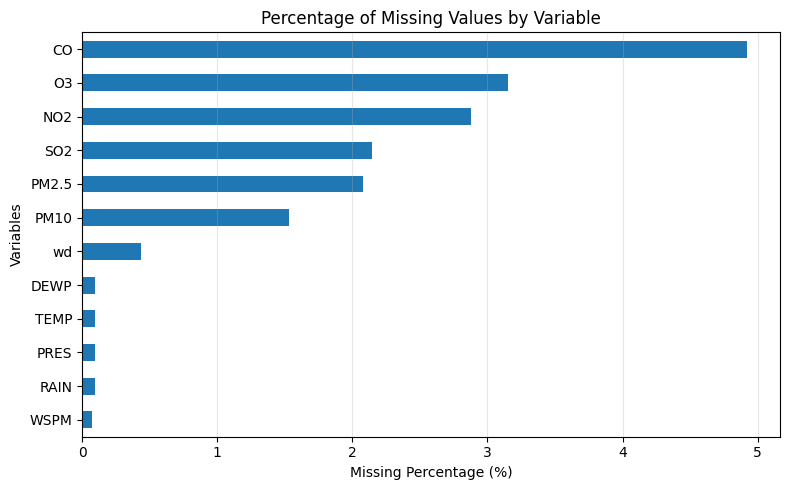

In [17]:
# ==========================================
# Visualize Missing Values
# ==========================================

import matplotlib.pyplot as plt

# Sort missing percentages in ascending order for horizontal plotting
plot_data = missing_df.sort_values(                        # Sort by % ascending
    by="Percentage (%)",
    ascending=True                                         # So least missing at bottom, most at top
)

# Create horizontal bar chart
plot_data.plot(                                            # Plot DataFrame
    kind="barh",                                           # Horizontal bar chart
    y="Percentage (%)",                                    # Use % column for bar length
    legend=False,                                          # Hide legend (not needed)
    figsize=(8, 5)                                         # Set figure size
)

# Add chart labels and title
plt.xlabel("Missing Percentage (%)")                       # Label x-axis
plt.ylabel("Variables")                                    # Label y-axis
plt.title("Percentage of Missing Values by Variable")      # Chart title

# Add gridlines for easier comparison
plt.grid(axis="x", alpha=0.3)                              # Light grid on x-axis

# Adjust layout and display the chart
plt.tight_layout()                                         # Optimize spacing
plt.show()                                                 # Render chart


### **Interpretation:**

#### **Missing Values Distribution**

* The bar chart provides a visual comparison of the percentage of missing observations across variables containing missing data.

* **CO** has the highest percentage of missing values at approximately **4.92%**, followed by **O3 (3.16%)**, **NO2 (2.88%)**, **SO2 (2.14%)**, **PM2.5 (2.08%)**, and **PM10 (1.53%)**.

#### **Meteorological Variables**

* The numerical meteorological variables contain substantially lower levels of missing data, with missing percentages below **0.1%**.

* Wind direction (**wd**) also contains a relatively small proportion of missing observations (**0.43%**) compared with the overall dataset.

#### **Overall Observation**

* The visualization confirms that no variable exceeds **5% missing observations**, with the highest level of missingness occurring in **CO**.

* Missingness is therefore limited relative to the total dataset size, but appropriate treatment is still required before exploratory analysis and machine learning model development.

* The missing-value handling strategy will be selected with consideration of the **temporal structure of the data and the one-hour-ahead forecasting objective**.

## **4.4 Distribution Analysis of Numerical Variables**

In [18]:
# ==========================================
# Distribution Analysis of Numerical Variables
# ==========================================

# Define numerical variables for distribution analysis
numerical_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# Generate descriptive statistics
summary_stats = df[numerical_cols].describe().T

print("=" * 60)
print("DESCRIPTIVE STATISTICS OF NUMERICAL VARIABLES")
print("=" * 60)

display(summary_stats)

# Calculate skewness for each numerical variable
skewness = df[numerical_cols].skew().sort_values(
    ascending=False
)

print("\n" + "=" * 60)
print("SKEWNESS OF NUMERICAL VARIABLES")
print("=" * 60)

display(skewness.to_frame(name="Skewness"))

DESCRIPTIVE STATISTICS OF NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
PM2.5,412029.0,79.793428,80.822391,2.0000,20.0,55.0,111.0,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.0,82.0,145.0,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.0,7.0,20.0,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.0,43.0,71.0,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.0,900.0,1500.0,10000.0
O3,407491.0,57.372271,56.661607,0.2142,11.0,45.0,82.0,1071.0
TEMP,420370.0,13.538976,11.436139,-19.9000,3.1,14.5,23.3,41.6
PRES,420375.0,1010.746982,10.474055,982.4000,1002.3,1010.4,1019.0,1042.8
DEWP,420365.0,2.490822,13.793847,-43.4000,-8.9,3.1,15.1,29.1
RAIN,420378.0,0.064476,0.821004,0.0000,0.0,0.0,0.0,72.5



SKEWNESS OF NUMERICAL VARIABLES


,Skewness
RAIN,30.043633
SO2,3.009503
CO,2.570129
PM2.5,2.013975
PM10,1.885835
O3,1.660095
WSPM,1.625590
NO2,1.050055
PRES,0.106314
TEMP,-0.104267


### **Interpretation:**

#### **Distribution of Numerical Variables**

* The skewness analysis indicates that several numerical variables have asymmetric distributions, with substantial variation in the degree of skewness across the dataset.

* **DEWP (-0.19)** and **TEMP (-0.10)** exhibit slight negative skewness, while **PRES (0.11)** is approximately symmetric, indicating relatively balanced distributions for these meteorological variables.

#### **Air Pollutant Variables**

* All six air pollutant variables exhibit **positive skewness**, indicating that observations are concentrated primarily at lower to moderate concentrations, with fewer observations occurring at substantially higher levels.

* **SO₂ (3.01)** and **CO (2.57)** show particularly strong positive skewness, followed by **PM2.5 (2.01)**, **PM10 (1.89)**, **O₃ (1.66)**, and **NO₂ (1.05)**.

* The large maximum values observed for several pollutants, such as **PM2.5 and PM10 (999 µg/m³)** and **CO (10,000 µg/m³)**, further indicate the presence of high-concentration observations that warrant examination during outlier analysis.

#### **Meteorological Variables**

* **Wind Speed (WSPM)** is positively skewed (**1.63**), indicating that lower wind speeds occur more frequently than very high wind speeds.

* **Rainfall (RAIN)** exhibits extremely high positive skewness (**30.04**). Its median and both the 25th and 75th percentiles are **0**, indicating that rainfall is absent for a large proportion of the hourly observations, while relatively few observations record substantial rainfall.

#### **Overall Observation**

* The descriptive statistics reveal substantial differences in the distributions and variability of the numerical variables, particularly among the pollutant measurements and rainfall.

* The strongly skewed distributions and high maximum values indicate the presence of potential extreme observations. These values should therefore be examined during the subsequent outlier analysis rather than automatically removed, as some may represent genuine high-pollution or meteorological events relevant to the forecasting objective.

## **4.5 Duplicate Record Analysis**

In [19]:
# ==========================================
# Duplicate Record Analysis
# ==========================================

# Count the total number of completely duplicated rows
duplicate_count = df.duplicated().sum()                     # .duplicated() flags duplicate rows, .sum() counts them

# Display the number of duplicate records
print(f"Number of duplicate records: {duplicate_count}")    # Print total duplicate count


Number of duplicate records: 0


### **Interpretation:**

* The dataset contains **no duplicate records**, indicating that each row represents a unique observation in the dataset.

* Therefore, **no duplicate records were removed**, and the dataset was retained without modification at this stage of preprocessing.

## **4.6 Missing Value Imputation**

In [20]:
# ==========================================
# Missing Value Imputation
# ==========================================

# Define numerical variables containing missing values
numerical_cols = [                                          # List of numeric columns to impute
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# ------------------------------------------------------------
# Sort observations chronologically within each station
# ------------------------------------------------------------

df = df.sort_values(                                        # Ensure time order per station
    by=['station', 'year', 'month', 'day', 'hour']          # Sort by station + timestamp parts
).reset_index(drop=True)                                    # Reset index after sorting

# ------------------------------------------------------------
# Forward-fill missing numerical values within each station
# Uses only previously observed values
# ------------------------------------------------------------

df[numerical_cols] = (                                      # Fill missing numeric values
    df.groupby('station')[numerical_cols]                   # Group by station
      .ffill()                                              # Forward-fill within each station
)

# ------------------------------------------------------------
# Forward-fill missing wind direction within each station
# ------------------------------------------------------------

df['wd'] = (                                                # Fill missing categorical values
    df.groupby('station')['wd']                             # Group by station
      .ffill()                                              # Forward-fill wind direction
)

# ------------------------------------------------------------
# Remove any observations that still contain missing values
# after forward filling
#
# These are typically observations occurring at the beginning
# of a station's time series, where no previous value exists.
# ------------------------------------------------------------

required_cols = numerical_cols + ['wd']                     # Columns required for modeling

remaining_before_drop = df[required_cols].isnull().any(axis=1).sum()
# Count rows still containing missing values after forward fill

df = df.dropna(                                             # Drop rows with missing values
    subset=required_cols                                    # Only check required columns
).reset_index(drop=True)                                    # Reset index after dropping

# ------------------------------------------------------------
# Verify missing values after preprocessing
# ------------------------------------------------------------

print("=" * 60)
print("MISSING VALUE IMPUTATION COMPLETED")
print("=" * 60)

print(                                                      # Report how many rows were removed
    "Rows removed because no previous observation was "
    "available for forward filling:",
    remaining_before_drop
)

print("\nRemaining Missing Values:")

display(                                                    # Show missing counts per column
    df[required_cols]
      .isnull()
      .sum()
      .to_frame(name="Missing Values")
)

print(                                                      # Show total missing values
    "\nTotal Remaining Missing Values:",
    df[required_cols].isnull().sum().sum()
)

print("\nDataset Shape After Missing Value Handling:", df.shape)
# Show final dataset dimensions


MISSING VALUE IMPUTATION COMPLETED
Rows removed because no previous observation was available for forward filling: 22

Remaining Missing Values:


,Missing Values
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0
TEMP,0
PRES,0
DEWP,0
RAIN,0



Total Remaining Missing Values: 0

Dataset Shape After Missing Value Handling: (420746, 18)


### **Interpretation:**

#### **Missing Value Treatment**

* Missing numerical values were handled using **station-wise forward filling**, with observations first arranged in chronological order within each monitoring station.

* This approach uses the most recently available preceding observation within the same station and therefore preserves the **temporal structure of the dataset** without using future observations to fill earlier missing values.

* After forward filling, only **22 observations** still contained missing values because no previous observation was available within the corresponding station to provide a value. These observations were removed from the dataset.

#### **Post-Imputation Verification**

* Following missing-value treatment, all required pollutant, meteorological, and wind-direction variables contained **zero missing values**.

* The dataset size decreased only slightly, from **420,768 to 420,746 observations**, meaning that approximately **99.99% of the original observations were retained**.

#### **Overall Observation**

* The missing-value treatment successfully produced a complete dataset for subsequent analysis while removing only a negligible number of observations.

* The use of **forward filling rather than backward filling** is consistent with the study's **one-hour-ahead forecasting framework**, as values from future observations were not used to impute earlier observations.

### **4.6.1 Post-Imputation Missing Value Verification**

In [21]:
# ==========================================
# Verify Missing Values After Imputation
# ==========================================

# Count remaining missing values in each variable
remaining_missing = df.isnull().sum()                       # Count NaNs per column after imputation

print("=" * 60)
print("MISSING VALUES AFTER IMPUTATION")
print("=" * 60)

# Convert to DataFrame for cleaner display
display(remaining_missing.to_frame(name="Missing Values"))  # Show counts in a single-column DataFrame


MISSING VALUES AFTER IMPUTATION


,Missing Values
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


### **Interpretation:**

* The post-imputation verification confirms that **all variables contain zero missing values**, indicating that the missing-value treatment was completed successfully.

* The dataset is therefore **complete with respect to missing values**, preventing missing-data-related errors during subsequent analysis and machine learning model development.

* Following missing-value treatment, the dataset is ready for **subsequent preprocessing, exploratory data analysis, and predictive model development**.

## **4.7 Outlier Detection**

### **4.7.1 Count Outliers using the IQR Method**

In [22]:
# ==========================================
# Potential Outlier Analysis Using IQR Method
# ==========================================

outlier_summary = []                                        # Empty list to store results

# Examine each numerical variable
for col in numerical_cols:

    # Calculate first and third quartiles
    Q1 = df[col].quantile(0.25)                             # 25th percentile
    Q3 = df[col].quantile(0.75)                             # 75th percentile

    # Calculate interquartile range
    IQR = Q3 - Q1                                           # Spread between Q3 and Q1

    # Define IQR-based lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR                            # Lower cutoff for outliers
    upper_bound = Q3 + 1.5 * IQR                            # Upper cutoff for outliers

    # Identify observations outside the IQR bounds
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    # Count potential outliers
    outlier_count = outlier_mask.sum()                      # Number of flagged rows

    # Calculate percentage of observations flagged
    outlier_percentage = (outlier_count / len(df)) * 100    # % of dataset flagged

    # Store results
    outlier_summary.append({
        "Variable": col,
        "Number of Potential Outliers": outlier_count,
        "Percentage (%)": round(outlier_percentage, 2)
    })

# Create summary DataFrame
outlier_df = pd.DataFrame(outlier_summary)                  # Convert list to DataFrame

# Display results
display(outlier_df)                                         # Show table of outlier counts + %


,Variable,Number of Potential Outliers,Percentage (%)
0,PM2.5,19168,4.56
1,PM10,14777,3.51
2,SO2,36572,8.69
3,NO2,7311,1.74
4,CO,30279,7.20
5,O3,17308,4.11
6,TEMP,0,0.00
7,PRES,0,0.00
8,DEWP,0,0.00
9,RAIN,16525,3.93


### **Interpretation:**

#### **Outlier Detection**

* Outlier detection was performed to identify **potential extreme observations** within the numerical variables of the dataset.

* The results indicate that potential outliers were identified in **SO₂ (36,572; 8.69%)**, **CO (30,279; 7.20%)**, **WSPM (23,111; 5.49%)**, **PM2.5 (19,168; 4.56%)**, **O₃ (17,308; 4.11%)**, **RAIN (16,525; 3.93%)**, **PM10 (14,777; 3.51%)**, and **NO₂ (7,311; 1.74%)**.

* In contrast, **TEMP, PRES, and DEWP** did not contain any potential outliers according to the applied detection criterion.

* The presence of extreme observations is plausible in environmental and air-quality data because pollutant concentrations and meteorological conditions can vary substantially across different periods and pollution events.

#### **Overall Observation**

* The identified potential outliers were **retained rather than automatically removed**, as extreme pollutant and meteorological observations may represent meaningful real-world conditions rather than data errors.

* Retaining these observations also allows the forecasting models to account for a broader range of environmental conditions, including periods of unusually high pollution.

### **4.7.2 Boxplots for Outlier Detection**

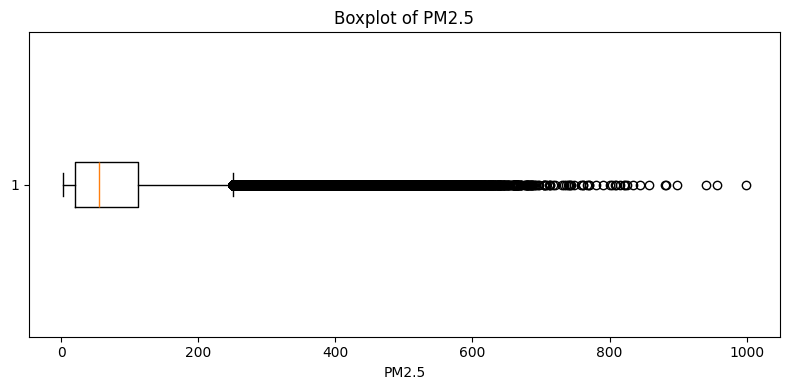

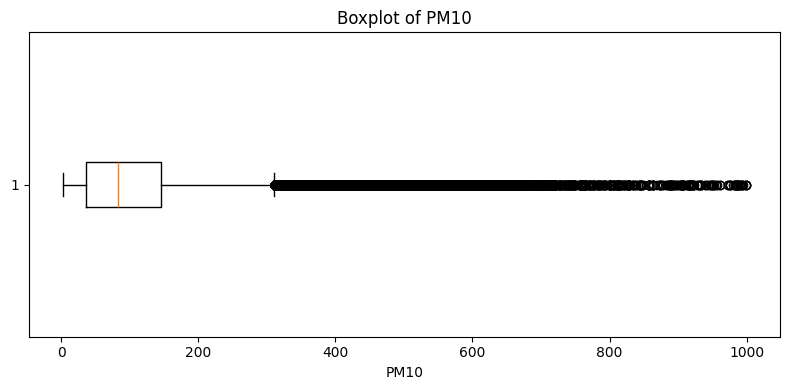

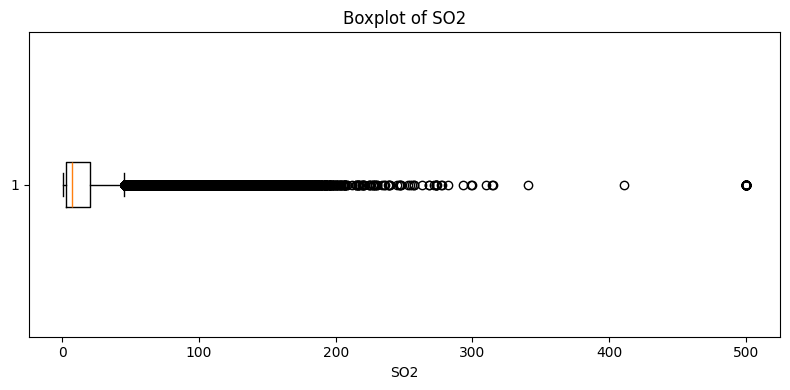

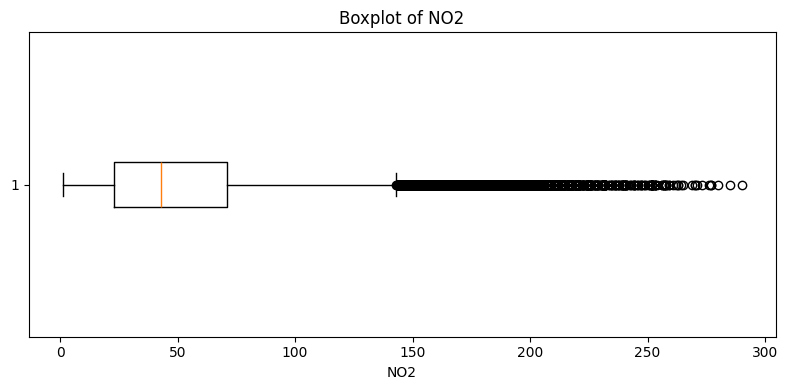

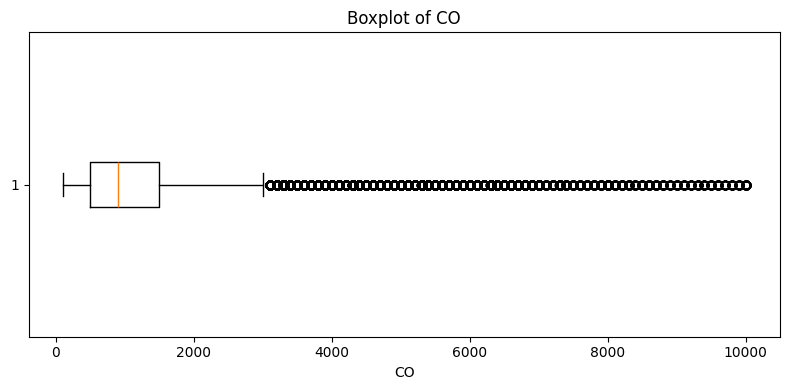

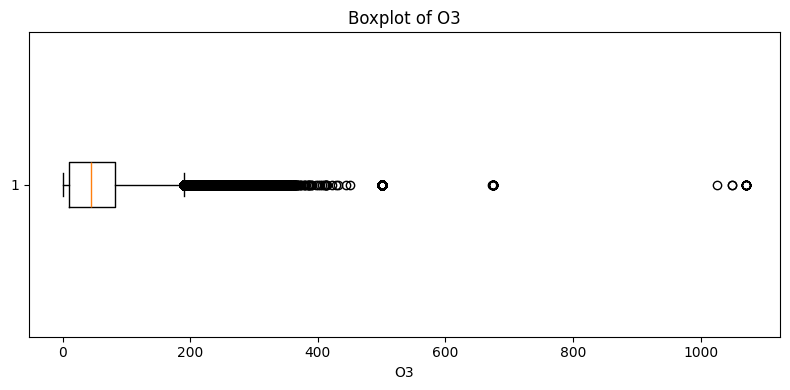

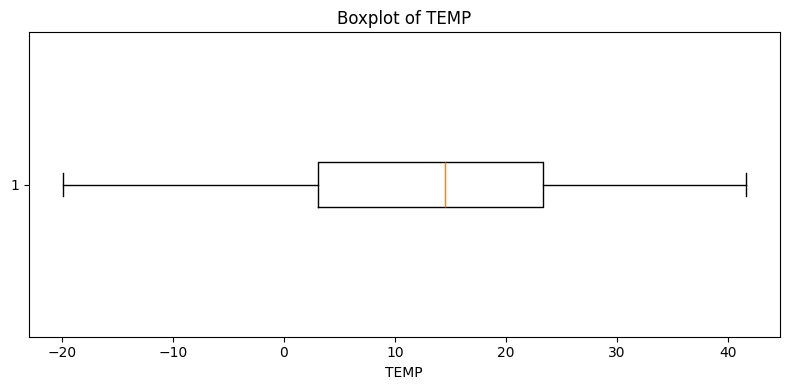

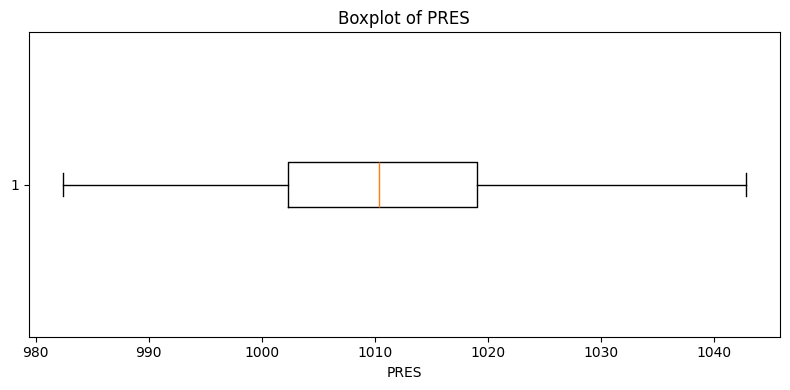

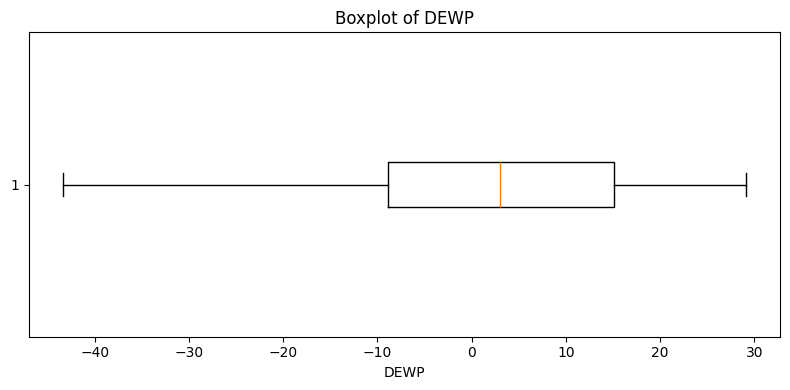

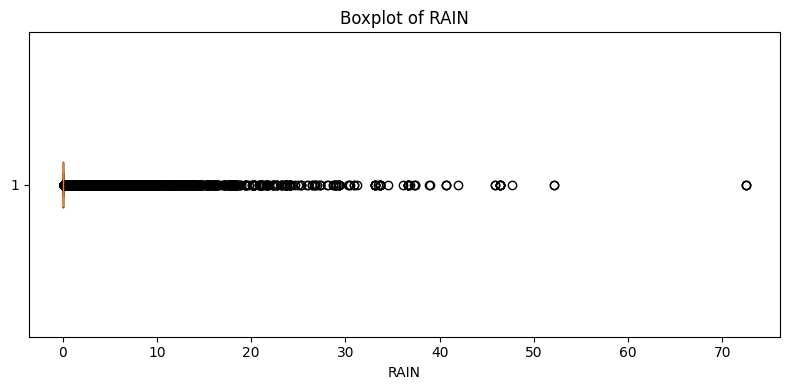

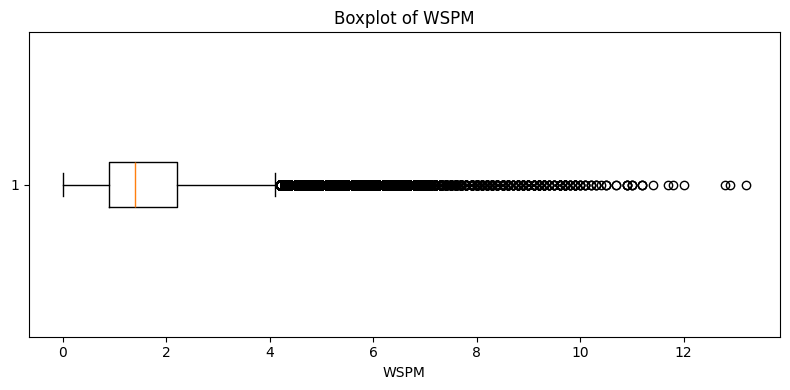

In [23]:
# ==========================================
# Boxplots for Potential Outlier Detection
# ==========================================

import matplotlib.pyplot as plt

# Create an individual boxplot for each numerical variable
for col in numerical_cols:                                 # Loop through each numeric column

    plt.figure(figsize=(8, 4))                             # Set figure size for clarity

    # Create horizontal boxplot
    plt.boxplot(                                           # Boxplot shows quartiles + outliers
        df[col].dropna(),                                  # Drop NaNs before plotting
        vert=False                                         # Horizontal orientation
    )

    # Add title and axis label
    plt.title(f"Boxplot of {col}")                         # Title with variable name
    plt.xlabel(col)                                        # Label x-axis with variable name

    # Improve layout
    plt.tight_layout()                                     # Adjust spacing for readability

    # Display plot
    plt.show()                                             # Render the plot


### **Interpretation:**

* The boxplots show clear differences in the distributions of the pollutant and meteorological variables.

* The pollutant variables **PM2.5, PM10, SO₂, NO₂, CO, and O₃** display numerous observations beyond their upper whiskers, indicating positively skewed distributions and the presence of high-concentration observations.

* Among the meteorological variables, **WSPM** also shows several upper-end potential outliers, while **RAIN** has a highly concentrated distribution around zero with relatively few larger rainfall observations.

* In contrast, **TEMP, PRES, and DEWP** show comparatively balanced distributions and no potential outliers according to the applied IQR criterion.

* These visual patterns are consistent with the numerical outlier analysis, which identified the highest proportion of potential outliers in **SO₂ (8.69%)**, followed by **CO (7.20%)** and **WSPM (5.49%)**.

* The potential outliers were **retained rather than automatically removed**, as extreme pollutant concentrations and meteorological conditions may represent meaningful real-world environmental events relevant to the forecasting objective.

## **4.8 Feature Engineering**

In [24]:
# ==========================================
# Feature Engineering
# Create Datetime Variable
# ==========================================

# Combine year, month, day, and hour into a single datetime variable
df["datetime"] = pd.to_datetime(                            # Build datetime column
    df[["year", "month", "day", "hour"]]                    # Combine year, month, day, hour
)

# Display the first few datetime values with monitoring station
display(df[["datetime", "station"]].head())                 # Preview datetime + station columns

# Verify the complete temporal coverage
print("Earliest Date and Time:", df["datetime"].min())      # Print earliest timestamp
print("Latest Date and Time:", df["datetime"].max())        # Print latest timestamp


,datetime,station
0,2013-03-01 00:00:00,Aotizhongxin
1,2013-03-01 01:00:00,Aotizhongxin
2,2013-03-01 02:00:00,Aotizhongxin
3,2013-03-01 03:00:00,Aotizhongxin
4,2013-03-01 04:00:00,Aotizhongxin


Earliest Date and Time: 2013-03-01 00:00:00
Latest Date and Time: 2017-02-28 23:00:00


### **Interpretation:**

#### **Feature Engineering**

* A new **datetime** feature was created by combining the existing **year, month, day, and hour** variables into a single timestamp.

* The resulting datetime feature spans from **March 1, 2013 at 00:00** to **February 28, 2017 at 23:00**, representing approximately four years of hourly observations.

* The **station** variable was retained to identify the monitoring location associated with each observation.

* The preview confirms that the datetime feature was created successfully and that each timestamp remains correctly associated with its corresponding monitoring station.

#### **Overall Observation**

* Creating the datetime feature provides a consistent temporal reference for arranging observations chronologically within each monitoring station.

* This temporal structure is essential for the subsequent **one-hour-ahead target construction, chronological train-test split, time-series cross-validation, and PM2.5 forecasting framework**.

### **4.9 Final Preprocessed Dataset Verification**

In [25]:
# ==========================================
# Final Preprocessed Dataset Verification
# ==========================================

# Display the dimensions of the preprocessed dataset
print("Dataset Shape:", df.shape)                          # Show total rows × columns

# Check for any remaining missing values
print("\nMissing Values After Preprocessing:")
remaining_missing = df.isnull().sum()                      # Count NaNs per column
display(remaining_missing.to_frame(name="Missing Values")) # Display as DataFrame for clarity

# Display the total number of remaining missing values
print("Total Remaining Missing Values:", remaining_missing.sum())  # Sum across all columns

# Display the first five rows of the preprocessed dataset
print("\nFirst Five Rows of the Preprocessed Dataset:")
display(df.head())                                         # Preview first 5 rows


Dataset Shape: (420746, 19)

Missing Values After Preprocessing:


,Missing Values
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


Total Remaining Missing Values: 0

First Five Rows of the Preprocessed Dataset:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


### **Interpretation:**

#### **Preprocessed Dataset**

* Following missing-value treatment and datetime feature creation, the preprocessed dataset contains **420,746 observations and 19 variables**.

* The verification confirms that **no missing values remain** across any of the variables in the preprocessed dataset.

* The first five observations show that the newly created **datetime** variable correctly represents the hourly timestamps and remains associated with the corresponding monitoring station.

#### **Overall Observation**

* The preprocessing stage produced a complete and chronologically structured dataset while retaining **420,746 of the original 420,768 observations**.

* The dataset is now ready for **exploratory data analysis and subsequent construction of the one-hour-ahead PM2.5 forecasting target**.

## **Save Final Preprocessed Dataset**


In [26]:
# ==========================================
# Save Final Preprocessed Dataset
# ==========================================

# Save the preprocessed dataset as a CSV file
df.to_csv(                                                  # Export DataFrame to CSV
    "air_quality_processed.csv",                            # File name
    index=False                                             # Exclude row indices from file
)

# Confirmation message
print("Preprocessed dataset saved successfully as 'air_quality_processed.csv'.")


Preprocessed dataset saved successfully as 'air_quality_processed.csv'.


### **Note:  Preprocessed Dataset Export**

The final preprocessed dataset was successfully saved as **`air_quality_processed.csv`** for use in subsequent exploratory analysis and machine learning model development.

# **5 Exploratory Data Analysis (EDA)**

* Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, identify trends, detect anomalies, and examine relationships between air pollutants and meteorological factors. These insights support feature selection and model development.

## **5.1: Distribution of PM2.5 Concentration**

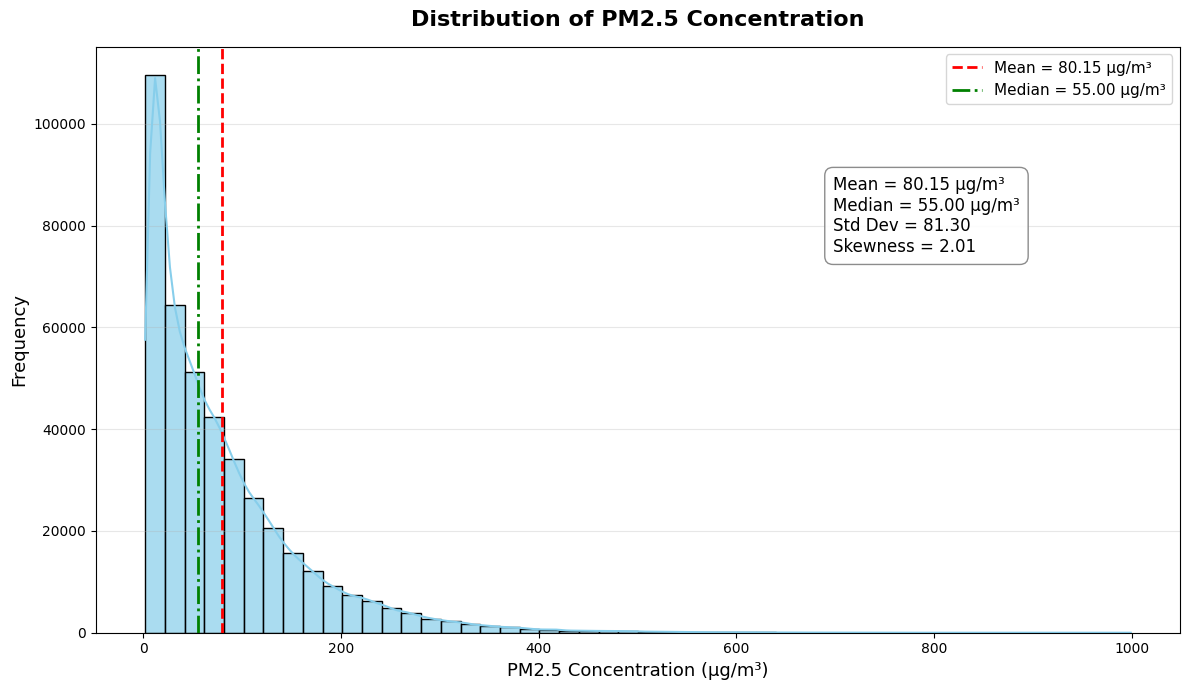

In [27]:
# ==========================================
# Distribution of PM2.5 Concentration
# ==========================================

import matplotlib.pyplot as plt                             # For plotting
import seaborn as sns                                       # For advanced plots (histogram + KDE)
from scipy.stats import skew                                # For skewness calculation

# Extract PM2.5 values
pm25 = df['PM2.5'].dropna()                                # Take PM2.5 column, drop missing values

# Calculate distribution statistics
mean_val = pm25.mean()                                     # Arithmetic mean (average)
median_val = pm25.median()                                 # Median (middle value)
skewness_val = skew(pm25)                                  # Skewness (symmetry/asymmetry measure)
std_val = pm25.std()                                       # Standard deviation (spread of values)

# Create histogram with density curve
plt.figure(figsize=(12, 7))                                # Set figure size (width=12, height=7)

sns.histplot(                                              # Histogram with density curve
    pm25,                                                  # Data: PM2.5 values
    bins=50,                                               # Number of bins
    kde=True,                                              # Add kernel density estimate curve
    color='skyblue',                                       # Bar color
    edgecolor='black',                                     # Bar edge color
    alpha=0.7                                              # Transparency
)

# Add reference line for mean
plt.axvline(
    mean_val,                                              # Position at mean
    color='red',                                           # Line color
    linestyle='--',                                        # Dashed line
    linewidth=2,                                           # Line thickness
    label=f'Mean = {mean_val:.2f} µg/m³'                   # Legend label with formatted mean
)

# Add reference line for median
plt.axvline(
    median_val,                                            # Position at median
    color='green',                                         # Line color
    linestyle='-.',                                        # Dash-dot line
    linewidth=2,                                           # Line thickness
    label=f'Median = {median_val:.2f} µg/m³'               # Legend label with formatted median
)

# Add title and axis labels
plt.title(
    'Distribution of PM2.5 Concentration',                 # Chart title
    fontsize=16,                                           # Title font size
    fontweight='bold',                                     # Bold title
    pad=15                                                 # Padding above title
)

plt.xlabel(
    'PM2.5 Concentration (µg/m³)',                         # X-axis label
    fontsize=13                                            # Font size
)

plt.ylabel(
    'Frequency',                                           # Y-axis label
    fontsize=13                                            # Font size
)

# Create statistical summary box
stats_text = (                                             # Text block with stats
    f'Mean = {mean_val:.2f} µg/m³\n'
    f'Median = {median_val:.2f} µg/m³\n'
    f'Std Dev = {std_val:.2f}\n'
    f'Skewness = {skewness_val:.2f}'
)

# Display statistics clearly inside the plot
plt.text(
    0.68,                                                  # X-position (relative to axes)
    0.78,                                                  # Y-position (relative to axes)
    stats_text,                                            # Text content
    transform=plt.gca().transAxes,                         # Use axis coordinates
    fontsize=12,                                           # Font size
    verticalalignment='top',                               # Align text at top
    bbox=dict(                                             # Box styling
        boxstyle='round,pad=0.5',                          # Rounded box with padding
        facecolor='white',                                 # White background
        edgecolor='gray',                                  # Gray border
        alpha=0.9                                          # Slight transparency
    )
)

# Improve readability
plt.grid(                                                  # Add gridlines
    axis='y',                                              # Only horizontal lines
    alpha=0.3                                              # Transparency
)

plt.legend(fontsize=11)                                    # Show legend for mean/median lines

plt.tight_layout()                                         # Optimize spacing

# Display plot
plt.show()                                                 # Render the plot


### **Interpretation**

#### **Analysis of PM2.5 Distribution**

* PM2.5 concentrations are concentrated at lower values, while relatively fewer observations occur at very high concentration levels, resulting in a pronounced **right-skewed distribution**.

* The calculated **skewness (2.01)** confirms substantial positive skewness, with high PM2.5 observations contributing to the extended upper tail of the distribution.

* The **mean PM2.5 concentration (80.15 µg/m³)** is considerably higher than the **median (55.00 µg/m³)**, further reflecting the influence of high-concentration observations on the overall average.

* The **standard deviation (81.30 µg/m³)** indicates considerable variability in PM2.5 concentrations across the dataset.

* Such variability is characteristic of air-quality data, where pollutant concentrations may fluctuate across different temporal, meteorological, and environmental conditions.

#### **Overall Observation**

* The analysis demonstrates that PM2.5 concentrations exhibit substantial variability and a strongly positively skewed distribution, with relatively few high-concentration observations forming a long upper tail.

* These high-concentration observations were retained because they may represent meaningful pollution episodes and are relevant to evaluating model performance across the full range of PM2.5 conditions.

### **5.1.1 Descriptive Statistics of PM2.5**

In [28]:
# ==========================================
# Descriptive Statistics of PM2.5
# ==========================================

pm25_summary = pd.DataFrame({
    'Statistic': [
        'Count',                        # Number of observations
        'Mean',                         # Average PM2.5 concentration
        'Median',                       # Middle value
        'Standard Deviation',           # Spread of values
        'Minimum',                      # Lowest observed value
        '25th Percentile (Q1)',         # Lower quartile
        '75th Percentile (Q3)',         # Upper quartile
        'Maximum',                      # Highest observed value
        'Skewness',                     # Asymmetry of distribution
        'Kurtosis'                      # Tail heaviness of distribution
    ],
    'Value': [
        round(pm25.count(), 0),         # Count of values
        round(pm25.mean(), 2),          # Mean
        round(pm25.median(), 2),        # Median
        round(pm25.std(), 2),           # Standard deviation
        round(pm25.min(), 2),           # Minimum
        round(pm25.quantile(0.25), 2),  # Q1
        round(pm25.quantile(0.75), 2),  # Q3
        round(pm25.max(), 2),           # Maximum
        round(pm25.skew(), 2),          # Skewness
        round(pm25.kurt(), 2)           # Kurtosis
    ]
})

# Display PM2.5 descriptive statistics
display(pm25_summary)

,Statistic,Value
0,Count,420746.00
1,Mean,80.15
2,Median,55.00
3,Standard Deviation,81.30
4,Minimum,2.00
5,25th Percentile (Q1),20.00
6,75th Percentile (Q3),112.00
7,Maximum,999.00
8,Skewness,2.01
9,Kurtosis,5.90


### **Interpretation**

#### **Summary Statistics of PM2.5**

* The PM2.5 variable contains **420,746 observations**, with concentrations ranging from **2.00 µg/m³ to 999.00 µg/m³**.

* The mean PM2.5 concentration is **80.15 µg/m³**, while the median is **55.00 µg/m³**. The higher mean relative to the median indicates that high-concentration observations influence the overall average.

* The middle 50% of PM2.5 observations lie between **20.00 µg/m³ (Q1)** and **112.00 µg/m³ (Q3)**, demonstrating substantial variation in pollutant concentrations across the dataset.

* The standard deviation of **81.30 µg/m³** further indicates considerable variability in PM2.5 concentrations.

* The positive **skewness of 2.01** confirms a strongly right-skewed distribution, with relatively fewer observations extending toward very high PM2.5 concentrations.

* The **kurtosis value of 5.90** indicates a distribution with relatively heavy tails, consistent with the presence of extreme high-concentration observations.

#### **Overall Observation**

* The summary statistics confirm substantial variability and positive skewness in PM2.5 concentrations, consistent with the histogram and boxplot findings.

* The high-concentration observations were retained because they may represent meaningful pollution episodes and are relevant to the study's **one-hour-ahead PM2.5 forecasting objective**.

## **5.2 Correlation Analysis**

### **5.2.1 Correlation Matrix**

In [29]:
# ==========================================
# Correlation Matrix
# ==========================================

# Define numerical variables for correlation analysis
numerical_cols = [                                          # List of numeric columns
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# Calculate Pearson correlation coefficients
correlation_matrix = df[numerical_cols].corr()              # Default method = Pearson correlation

# Display correlation matrix rounded to two decimal places
display(correlation_matrix.round(2))                        # Show clean table with 2-decimal precision


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.00,0.88,0.47,0.65,0.77,-0.14,-0.13,0.02,0.11,-0.01,-0.27
PM10,0.88,1.00,0.45,0.64,0.69,-0.11,-0.10,-0.02,0.07,-0.03,-0.18
SO2,0.47,0.45,1.00,0.48,0.51,-0.16,-0.32,0.22,-0.26,-0.04,-0.11
NO2,0.65,0.64,0.48,1.00,0.68,-0.45,-0.27,0.17,-0.03,-0.04,-0.39
CO,0.77,0.69,0.51,0.68,1.00,-0.30,-0.33,0.19,-0.07,-0.01,-0.29
O3,-0.14,-0.11,-0.16,-0.45,-0.30,1.00,0.58,-0.44,0.31,0.02,0.29
TEMP,-0.13,-0.10,-0.32,-0.27,-0.33,0.58,1.00,-0.81,0.82,0.04,0.03
PRES,0.02,-0.02,0.22,0.17,0.19,-0.44,-0.81,1.00,-0.75,-0.06,0.07
DEWP,0.11,0.07,-0.26,-0.03,-0.07,0.31,0.82,-0.75,1.00,0.09,-0.30
RAIN,-0.01,-0.03,-0.04,-0.04,-0.01,0.02,0.04,-0.06,0.09,1.00,0.02


### **Interpretation**

#### **Correlation of Predictor Variables with PM2.5**

* **PM10** shows the strongest positive correlation with PM2.5 (**r = 0.88**), indicating that higher PM10 concentrations tend to occur alongside higher PM2.5 concentrations.

* **CO** also exhibits a strong positive correlation with PM2.5 (**r = 0.77**), while **NO₂** shows a moderately strong positive correlation (**r = 0.65**).

* **SO₂** has a moderate positive correlation with PM2.5 (**r = 0.47**).

* Among the meteorological variables, **wind speed (WSPM)** has the strongest relationship with PM2.5 and shows a negative correlation (**r = -0.27**). This indicates that higher wind speeds tend to be associated with lower PM2.5 concentrations.

* **O₃ (r = -0.14)** and **TEMP (r = -0.13)** show weak negative correlations with PM2.5, while **DEWP (r = 0.11)** shows a weak positive correlation.

* **PRES (r = 0.02)** and **RAIN (r = -0.01)** show very weak linear relationships with PM2.5.

#### **Relationships Among Predictor Variables**

* Strong correlations are also observed among some predictor variables. **TEMP and DEWP** are strongly positively correlated (**r = 0.82**), while **TEMP and PRES** show a strong negative correlation (**r = -0.81**).

* **PRES and DEWP** also exhibit a strong negative correlation (**r = -0.75**), indicating substantial relationships among the meteorological variables.

#### **Overall Observation**

* The correlation analysis indicates that PM2.5 is most strongly associated with other pollutant variables, particularly **PM10, CO, and NO₂**, while meteorological variables generally show weaker direct linear relationships with PM2.5.

* These correlations describe statistical associations and should **not be interpreted as evidence of causation**.

* The presence of correlations among predictor variables will be considered during model development and interpretation.

### **5.2.2 Correlation Heatmap**

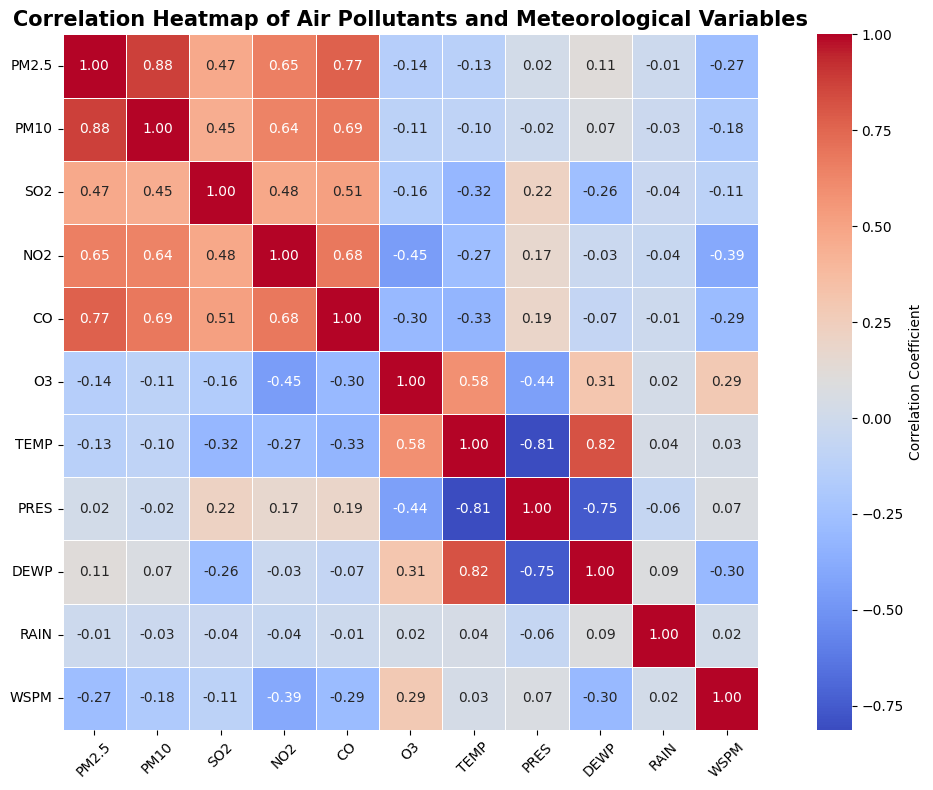

In [30]:
# ==========================================
# 5.2.2 Correlation Heatmap
# ==========================================

plt.figure(figsize=(12, 8))                  # Set figure size

sns.heatmap(                                 # Create heatmap
    correlation_matrix,                      # Use correlation matrix
    annot=True,                              # Show correlation values
    cmap='coolwarm',                         # Color scheme (blue-red)
    fmt='.2f',                               # Format numbers to 2 decimals
    linewidths=0.5,                          # Thin lines between cells
    square=True,                             # Keep cells square-shaped
    cbar_kws={'label': 'Correlation Coefficient'}  # Label for color bar
)

plt.title(                                   # Add title
    'Correlation Heatmap of Air Pollutants and Meteorological Variables',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=45)                      # Rotate x-axis labels for readability
plt.yticks(rotation=0)                       # Keep y-axis labels horizontal

plt.tight_layout()                           # Adjust layout to fit labels
plt.show()                                   # Display the heatmap


### **Interpretation:**

* The heatmap provides a visual representation of the relationships among air pollutants and meteorological variables, where warmer colours indicate positive correlations and cooler colours indicate negative correlations.

* **PM2.5** exhibits strong positive correlations with **PM10 (r = 0.88)** and **CO (r = 0.77)**, indicating that higher concentrations of these pollutants tend to occur alongside higher PM2.5 concentrations.

* A moderately strong positive correlation is observed between **PM2.5 and NO₂ (r = 0.65)**, while **SO₂ (r = 0.47)** shows a moderate positive relationship with PM2.5.

* Meteorological variables display comparatively weaker direct linear relationships with PM2.5. **WSPM (r = -0.27)** and **TEMP (r = -0.13)** show negative correlations, while **PRES (r = 0.02)** shows very little linear relationship with PM2.5.

* Strong relationships are also evident among some meteorological variables, particularly between **TEMP and DEWP (r = 0.82)**, **TEMP and PRES (r = -0.81)**, and **PRES and DEWP (r = -0.75)**.

### **Overall Observation**

* The heatmap indicates that **PM2.5 exhibits stronger correlations with other air pollutants than with the individual meteorological variables**.

* The observed correlations represent statistical associations and **should not be interpreted as evidence of causal relationships**.

## **5.3 Monthly Variation of PM2.5**

,month,PM2.5
0,1,94.021657
1,2,89.164457
2,3,94.814186
3,4,73.854074
4,5,64.194461
5,6,68.960854
6,7,71.974628
7,8,53.648863
8,9,61.401175
9,10,92.208137


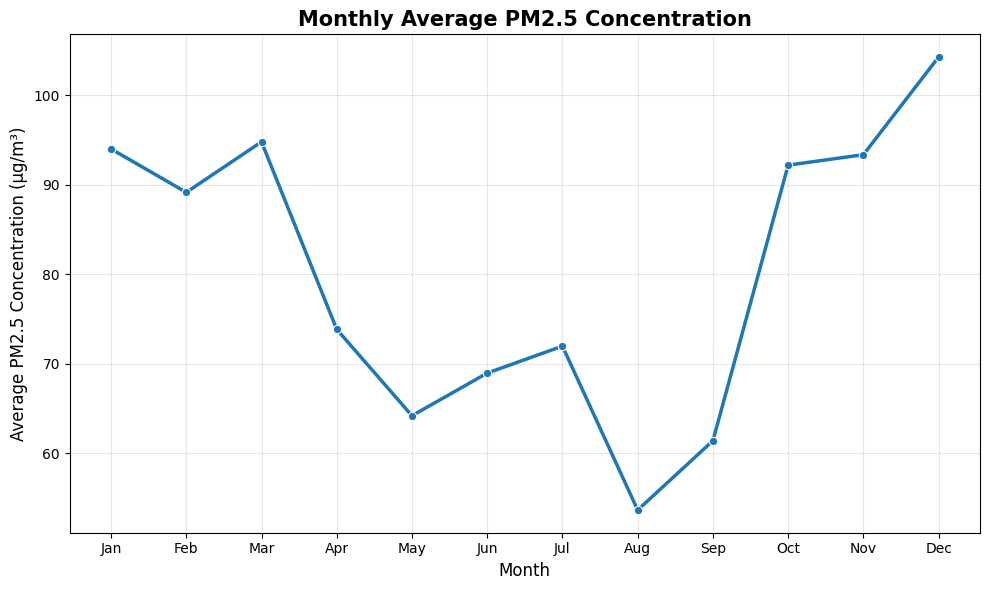

In [31]:
# ==========================================
# Monthly Average PM2.5 Analysis
# ==========================================

# Calculate average PM2.5 concentration for each calendar month
monthly_pm25 = (                                            # Group by month
    df.groupby('month')['PM2.5']                            # Select PM2.5 column
      .mean()                                               # Compute mean per month
      .reset_index()                                        # Reset index for clean DataFrame
)

# Display monthly average PM2.5 concentrations
display(monthly_pm25)                                       # Show table of monthly averages

# Create line plot
plt.figure(figsize=(10, 6))                                 # Set figure size

sns.lineplot(                                               # Line plot of monthly averages
    data=monthly_pm25,
    x='month',
    y='PM2.5',
    marker='o',                                             # Add markers at each point
    linewidth=2.5                                           # Thicker line for clarity
)

# Add chart title and axis labels
plt.title(
    'Monthly Average PM2.5 Concentration',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Month', fontsize=12)                            # Label x-axis
plt.ylabel('Average PM2.5 Concentration (µg/m³)', fontsize=12) # Label y-axis

# Display month names on x-axis
plt.xticks(                                                 # Replace numbers with month names
    ticks=range(1, 13),
    labels=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
    ]
)

# Improve readability
plt.grid(alpha=0.3)                                         # Light gridlines
plt.tight_layout()                                          # Optimize spacing

# Display plot
plt.show()


### **Interpretation:**

* The monthly analysis reveals a clear **seasonal pattern in average PM2.5 concentrations**.

* **December** records the highest average PM2.5 concentration at approximately **104.30 µg/m³**, while **August** records the lowest at approximately **53.65 µg/m³**.

* Average PM2.5 concentrations are relatively high during **January to March**, decline substantially from **April through August**, and begin increasing again from **September**.

* A particularly noticeable increase occurs between **September (61.40 µg/m³)** and **October (92.21 µg/m³)**, followed by consistently high average concentrations during **November and December**.

### **Overall Observation**

* The results demonstrate substantial **month-to-month variation in PM2.5 concentrations**, with higher average levels toward the beginning and end of the year and lower levels during the middle months.

* This temporal variation suggests that **month may provide useful predictive information** when modelling one-hour-ahead PM2.5 concentrations.

## **5.4 Station-wise PM2.5 Analysis**

### **5.4.1 Average PM2.5 by Station**

In [32]:
# ==========================================
# Average PM2.5 Concentration by Station
# ==========================================

station_pm25 = (                              # Create new DataFrame
    df.groupby('station')['PM2.5']            # Group data by station
      .mean()                                 # Calculate mean PM2.5 for each station
      .sort_values(ascending=False)           # Sort stations by average PM2.5 (highest first)
      .reset_index()                          # Reset index so 'station' becomes a column
)

# Display station-wise average PM2.5 concentrations
display(station_pm25)


,station,PM2.5
0,Dongsi,86.310293
1,Wanshouxigong,85.356562
2,Nongzhanguan,85.289471
3,Gucheng,84.389145
4,Wanliu,83.516054
5,Aotizhongxin,83.163652
6,Guanyuan,83.047023
7,Tiantan,82.255892
8,Shunyi,80.021067
9,Changping,71.119444


### **Interpretation:**

* Average PM2.5 concentrations vary across the **12 monitoring stations**, indicating spatial variation in air pollution levels within the dataset.

* **Dongsi** records the highest average PM2.5 concentration at approximately **86.31 µg/m³**, followed by **Wanshouxigong (85.36 µg/m³)** and **Nongzhanguan (85.29 µg/m³)**.

* In contrast, **Dingling** records the lowest average PM2.5 concentration at approximately **67.43 µg/m³**, followed by **Huairou (69.95 µg/m³)** and **Changping (71.12 µg/m³)**.

* The difference between the highest and lowest station averages is approximately **18.88 µg/m³**, demonstrating noticeable variation in PM2.5 concentrations across monitoring locations.

### **Overall Observation**

* The station-level analysis indicates that PM2.5 concentrations are not uniform across monitoring locations.

* This spatial variation suggests that the **station variable may provide useful predictive information** when modelling one-hour-ahead PM2.5 concentrations.

### **5.4.2 Bar Chart**

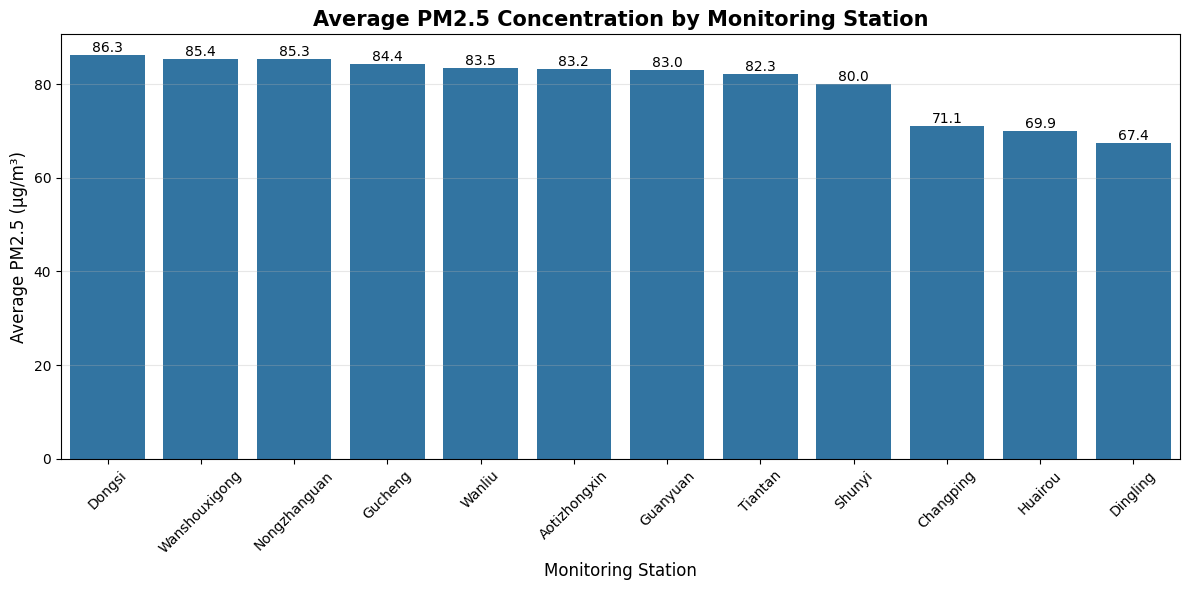

In [33]:
# ==========================================
# Bar Chart of Average PM2.5 by Station
# ==========================================

plt.figure(figsize=(12,6))                     # Set figure size

ax = sns.barplot(                              # Create bar chart
    data=station_pm25,                         # Use station-level averages
    x='station',                               # Stations on x-axis
    y='PM2.5'                                  # Average PM2.5 on y-axis
)

# Add value labels on top of bars
for container in ax.containers:                # Loop through bar containers
    ax.bar_label(container, fmt='%.1f', fontsize=10)  # Show values with 1 decimal

plt.title(                                     # Add chart title
    'Average PM2.5 Concentration by Monitoring Station',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Monitoring Station', fontsize=12)  # Label x-axis
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12) # Label y-axis

plt.xticks(rotation=45)                        # Rotate station names for readability

plt.grid(axis='y', alpha=0.3)                  # Add horizontal gridlines

plt.tight_layout()                             # Adjust layout to fit labels

plt.show()                                     # Display the plot


### **Interpretation:**

* The bar chart shows noticeable variation in average PM2.5 concentrations across the **12 monitoring stations**.

* **Dongsi** records the highest average PM2.5 concentration at approximately **86.3 µg/m³**, followed closely by **Wanshouxigong (85.4 µg/m³)** and **Nongzhanguan (85.3 µg/m³)**.

* **Dingling** records the lowest average concentration at approximately **67.4 µg/m³**, followed by **Huairou (69.9 µg/m³)** and **Changping (71.1 µg/m³)**.

* Overall, the visualization confirms **spatial variation in PM2.5 concentrations across monitoring locations**, suggesting that the **station variable may provide useful predictive information** for one-hour-ahead PM2.5 forecasting.

### **5.4.3 Highest and Lowest Pollution Stations**

In [34]:
# ==========================================
# Highest and Lowest Average PM2.5 Stations
# ==========================================

# Identify the station with the highest average PM2.5 concentration
highest_station = station_pm25.iloc[0]                     # First row (sorted descending)

# Identify the station with the lowest average PM2.5 concentration
lowest_station = station_pm25.iloc[-1]                     # Last row (lowest average)

# Display highest average PM2.5 station
print("Highest Average PM2.5 Station:")
print(
    f"{highest_station['station']} : "                     # Station name
    f"{highest_station['PM2.5']:.2f} µg/m³"                # Value formatted to 2 decimals
)

# Display lowest average PM2.5 station
print("\nLowest Average PM2.5 Station:")
print(
    f"{lowest_station['station']} : "                      # Station name
    f"{lowest_station['PM2.5']:.2f} µg/m³"                 # Value formatted to 2 decimals
)


Highest Average PM2.5 Station:
Dongsi : 86.31 µg/m³

Lowest Average PM2.5 Station:
Dingling : 67.43 µg/m³


### **Key Observation:**

* **Dongsi** recorded the highest average PM2.5 concentration (**86.31 µg/m³**), while **Dingling** recorded the lowest (**67.43 µg/m³**), further demonstrating spatial variation in PM2.5 concentrations across the monitoring stations.

## **5.5 Relationship Between Meteorological Variables and PM2.5**

### **5.5.1 Scatter Plots**

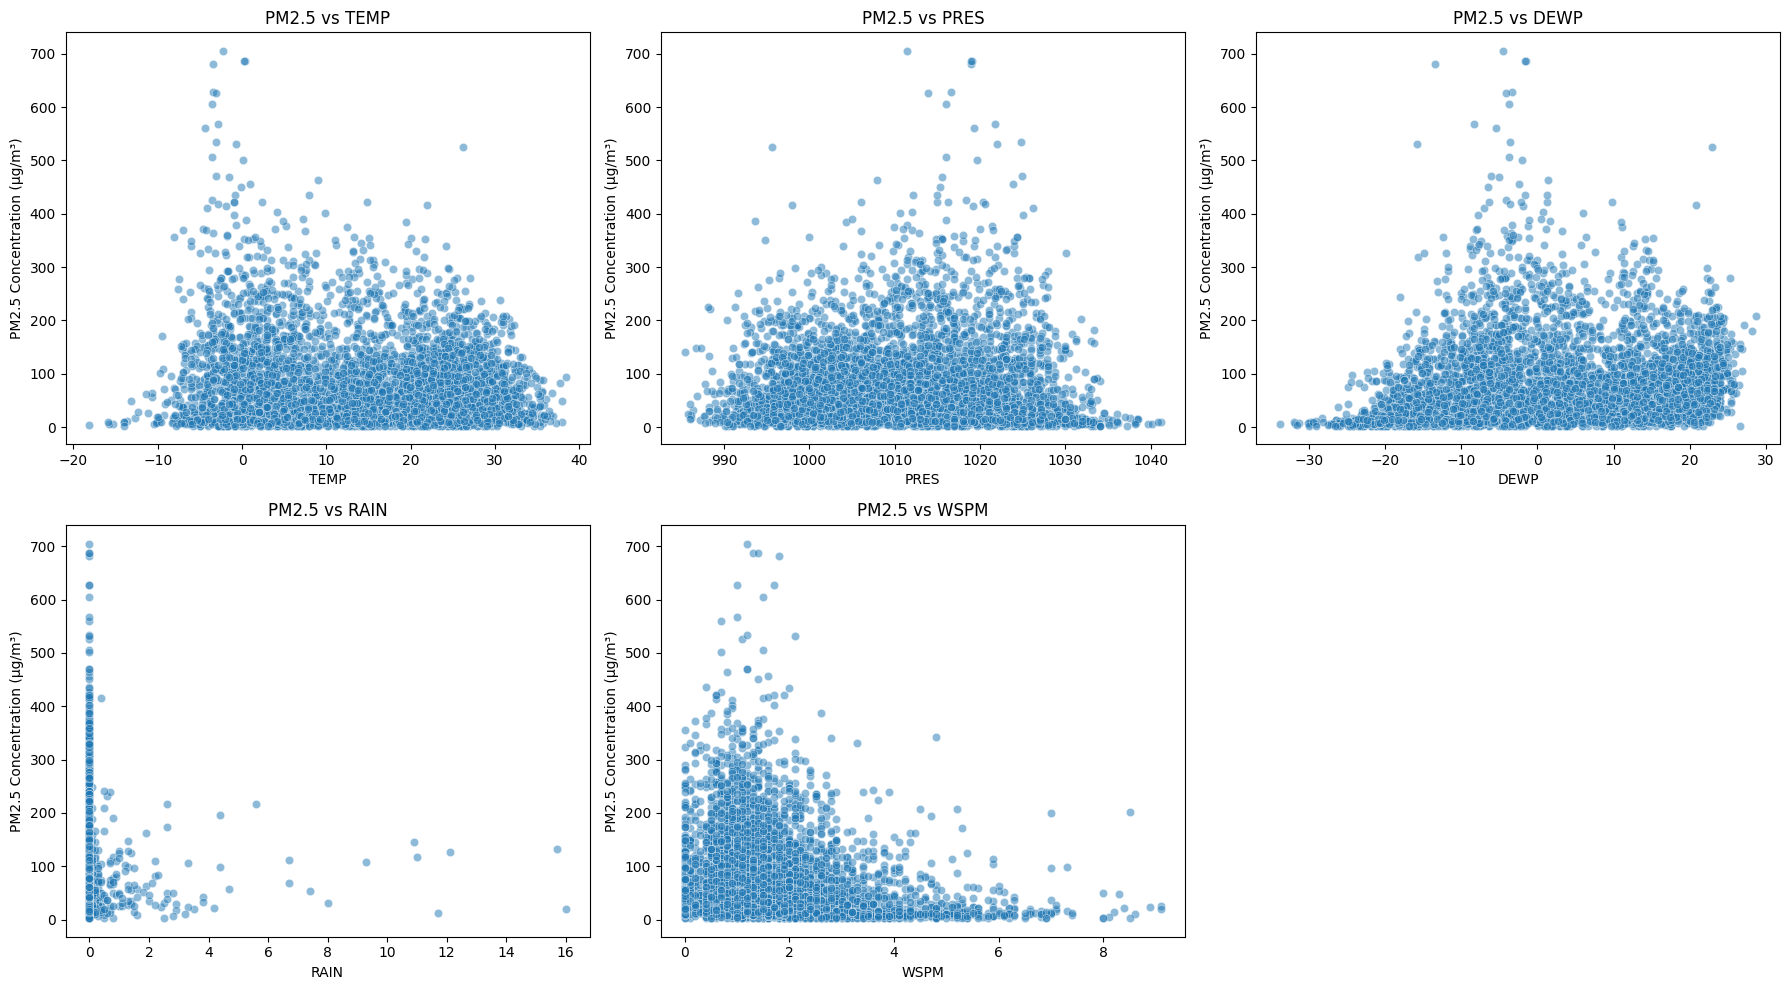

In [35]:
# ==========================================
# Relationship Between Meteorological Variables and PM2.5
# ==========================================

# Define meteorological variables
meteorological_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']   # Weather variables to compare

# Create one reproducible sample for visualization
sample_df = df.sample(                                          # Random sample for faster plotting
    n=5000,                                                     # Use 5,000 rows
    random_state=42                                             # Fixed seed for reproducibility
)

# Create figure
plt.figure(figsize=(18, 10))                                    # Large figure for multiple subplots

# Generate scatterplots for each meteorological variable
for i, var in enumerate(meteorological_vars, 1):                # Loop through variables with index

    plt.subplot(2, 3, i)                                        # Create subplot grid (2 rows × 3 cols)

    sns.scatterplot(                                            # Scatter plot for each variable
        data=sample_df,
        x=var,                                                  # Meteorological variable on x-axis
        y='PM2.5',                                              # PM2.5 concentration on y-axis
        alpha=0.5                                               # Semi-transparent points
    )

    # Add subplot title and axis labels
    plt.title(f'PM2.5 vs {var}')                                # Title for each subplot
    plt.xlabel(var)                                             # Label x-axis
    plt.ylabel('PM2.5 Concentration (µg/m³)')                   # Label y-axis

# Adjust layout and display
plt.tight_layout()                                              # Prevent overlap
plt.show()                                                      # Display all subplots


### **Interpretation:**

* The scatterplots illustrate the relationships between **PM2.5 concentrations and selected meteorological variables**.

* **Temperature (TEMP)** shows a weak negative relationship with PM2.5, consistent with its correlation coefficient of **r = -0.13**.

* **Atmospheric pressure (PRES)** shows little apparent linear relationship with PM2.5 (**r = 0.02**), while **dew point temperature (DEWP)** exhibits a weak positive relationship (**r = 0.11**).

* **Rainfall (RAIN)** shows almost no linear relationship with PM2.5 (**r = -0.01**). Most rainfall observations are concentrated near zero, which is consistent with the highly skewed rainfall distribution identified earlier.

* **Wind speed (WSPM)** shows the most noticeable negative relationship among the meteorological variables displayed (**r = -0.27**), with higher wind-speed observations generally associated with lower PM2.5 concentrations.

### **Overall Observation**

* The scatterplots indicate that the individual meteorological variables generally have **weak linear relationships with PM2.5**, with wind speed showing the strongest negative association among the variables examined.

* The wide dispersion of observations suggests that PM2.5 concentrations are not explained by any single meteorological variable alone, supporting the use of multiple predictor variables in the forecasting models.

### **5.5.2 Correlation of Meteorological Variables with PM2.5**

* This analysis describes the contemporaneous relationship between meteorological variables and **current-hour PM2.5 concentrations** in the original dataset. Forecasting-specific relationships with the one-hour-ahead target are examined separately before model development.

In [36]:
# ==========================================
# Correlation of Meteorological Variables with PM2.5
# ==========================================

pm25_corr = (                                # Create correlation series
    df[meteorological_vars + ['PM2.5']]      # Select meteorological variables + PM2.5
      .corr()['PM2.5']                       # Compute correlation matrix, extract PM2.5 column
      .drop('PM2.5')                         # Drop self-correlation (always 1.0)
      .sort_values(ascending=False)          # Sort correlations from strongest positive to weakest
)

# Display correlations rounded to three decimal places
display(
    pm25_corr.round(3).to_frame(
        name='Correlation with PM2.5'
    )
)


,Correlation with PM2.5
DEWP,0.113
PRES,0.019
RAIN,-0.014
TEMP,-0.131
WSPM,-0.270


### **Interpretation:**

* **WSPM** shows the strongest association with PM2.5 among the meteorological variables, with a **weak negative correlation (r = -0.270)**.

* **TEMP** also shows a **weak negative correlation (r = -0.131)**, while **DEWP** shows a **weak positive correlation (r = 0.113)** with PM2.5.

* **PRES (r = 0.019)** and **RAIN (r = -0.014)** exhibit negligible linear relationships with PM2.5.

### **Overall Observation**

* Overall, the meteorological variables individually show relatively **weak linear relationships with PM2.5**, with **wind speed (WSPM)** demonstrating the strongest association among the variables examined.

* These findings indicate that no single meteorological variable alone strongly explains PM2.5 variation, supporting the use of **multiple predictor variables** in the forecasting models.

## **5.6 Transition to One-Hour-Ahead Forecasting**

* The exploratory data analysis above examined the patterns and relationships present in the original air quality dataset. Based on mentor feedback, the predictive task was subsequently defined as a **one-hour-ahead PM2.5 forecasting problem**.

* Accordingly, the modelling stage uses information available at the current hour **(t)** to forecast PM2.5 concentration one hour ahead **(t+1)**. The forecasting target and modelling framework are defined in the following section.

# **6. Model Development**

## **6.1 Forecasting Horizon**

* Based on mentor feedback, the prediction task was defined as a one-hour-ahead forecasting problem. The objective is to use environmental, meteorological, temporal, and location-related information available at the current hour (t) to predict PM2.5 concentration one hour ahead (t+1).

* A one-hour forecasting horizon was selected because the dataset contains hourly observations and this provides a practical short-term air quality forecasting framework.

In [37]:
# ============================================================
# Create One-Hour-Ahead PM2.5 Forecasting Target
# ============================================================

# Sort observations chronologically within each monitoring station
df = df.sort_values(                                        # Ensure time order per station
    by=['station', 'datetime']
).reset_index(drop=True)

# Obtain the timestamp and PM2.5 value of the next observation
df['next_datetime'] = (                                     # Next timestamp per station
    df.groupby('station')['datetime']
      .shift(-1)                                            # Shift backward by 1 row
)

df['PM2.5_next_hour'] = (                                   # Next-hour PM2.5 per station
    df.groupby('station')['PM2.5']
      .shift(-1)
)

# Calculate time difference between consecutive observations
df['time_gap'] = df['next_datetime'] - df['datetime']       # Difference between current and next

# Retain only observations where the target is exactly one hour ahead
df_forecast = df[                                           # Filter rows
    df['time_gap'] == pd.Timedelta(hours=1)                 # Keep only 1-hour gaps
].copy()

print("Original dataset shape:", df.shape)                  # Print original dataset size
print("Forecasting dataset shape:", df_forecast.shape)      # Print filtered dataset size

# Display preview of forecasting dataset
display(
    df_forecast[
        [
            'station',
            'datetime',
            'PM2.5',
            'next_datetime',
            'PM2.5_next_hour'
        ]
    ].head(10)
)


Original dataset shape: (420746, 22)
Forecasting dataset shape: (420734, 22)


,station,datetime,PM2.5,next_datetime,PM2.5_next_hour
0,Aotizhongxin,2013-03-01 00:00:00,4.0,2013-03-01 01:00:00,8.0
1,Aotizhongxin,2013-03-01 01:00:00,8.0,2013-03-01 02:00:00,7.0
2,Aotizhongxin,2013-03-01 02:00:00,7.0,2013-03-01 03:00:00,6.0
3,Aotizhongxin,2013-03-01 03:00:00,6.0,2013-03-01 04:00:00,3.0
4,Aotizhongxin,2013-03-01 04:00:00,3.0,2013-03-01 05:00:00,5.0
5,Aotizhongxin,2013-03-01 05:00:00,5.0,2013-03-01 06:00:00,3.0
6,Aotizhongxin,2013-03-01 06:00:00,3.0,2013-03-01 07:00:00,3.0
7,Aotizhongxin,2013-03-01 07:00:00,3.0,2013-03-01 08:00:00,3.0
8,Aotizhongxin,2013-03-01 08:00:00,3.0,2013-03-01 09:00:00,3.0
9,Aotizhongxin,2013-03-01 09:00:00,3.0,2013-03-01 10:00:00,3.0


### **Interpretation:**

#### **One-Hour-Ahead Forecasting Target**

* A one-hour-ahead forecasting target, **PM2.5_next_hour**, was created by shifting the PM2.5 concentration forward by one hour within each monitoring station.

* Each observation therefore contains the predictor information available at the **current time (t)**, while the target variable represents the PM2.5 concentration at the **next hour (t + 1)**.

* The displayed observations confirm that the forecasting target is correctly aligned. For example, at **Aotizhongxin**, the PM2.5 concentration at **2013-03-01 00:00:00** is **4.0 µg/m³**, while the corresponding next-hour target at **01:00:00** is **8.0 µg/m³**.

* The dataset size decreased from **420,746 to 420,734 observations**, representing the removal of **12 observations**. These correspond to the final observation from each of the **12 monitoring stations**, for which a subsequent one-hour PM2.5 value is unavailable.

### **Overall Observation**

* The forecasting dataset is correctly structured for the study's objective of predicting **PM2.5 concentration one hour ahead** using information available at the current observation time.

### **6.1.1 Forecasting-Specific Exploratory Analysis**
 * Following the creation of the **PM2.5_next_hour** target variable, an additional exploratory analysis was conducted to examine the relationships between information available at the current hour **(t)** and PM2.5 concentration one hour ahead **(t+1)**.

This forecasting-specific analysis complements the earlier EDA, which examined relationships with current-hour PM2.5 concentrations.

#### **Correlation with One-Hour-Ahead PM2.5**

In [38]:
# ============================================================
# Correlation with One-Hour-Ahead PM2.5
# ============================================================

forecast_numeric_vars = [                                   # Variables to include in correlation
    'PM2.5',
    'PM10',
    'SO2',
    'NO2',
    'CO',
    'O3',
    'TEMP',
    'PRES',
    'DEWP',
    'RAIN',
    'WSPM',
    'PM2.5_next_hour'                                       # Forecast target
]

# Calculate correlations with the forecasting target
forecast_corr = (                                           # Compute correlation series
    df_forecast[forecast_numeric_vars]                      # Select relevant variables
    .corr()['PM2.5_next_hour']                              # Extract correlations with target
    .drop('PM2.5_next_hour')                                # Drop trivial self-correlation
    .sort_values(ascending=False)                           # Sort descending (strongest positive first)
)

print("CORRELATION WITH ONE-HOUR-AHEAD PM2.5")
print("=" * 50)

display(forecast_corr)                                      # Show ranked correlations


CORRELATION WITH ONE-HOUR-AHEAD PM2.5


,PM2.5_next_hour
PM2.5,0.968270
PM10,0.859196
CO,0.757679
NO2,0.654296
SO2,0.464737
DEWP,0.113029
PRES,0.021473
RAIN,-0.028491
TEMP,-0.131560
O3,-0.148029


### **Interpretation:**

#### **Correlation with One-Hour-Ahead PM2.5**

* **Current-hour PM2.5** shows the strongest positive correlation with **one-hour-ahead PM2.5**, with a correlation coefficient of **r = 0.968**. This indicates strong short-term persistence in PM2.5 concentrations from one hour to the next.

* Among the other pollutant variables, **PM10 (r = 0.859)** and **CO (r = 0.758)** show strong positive correlations with next-hour PM2.5.

* **NO₂ (r = 0.654)** shows a moderately strong positive correlation, while **SO₂ (r = 0.465)** exhibits a moderate positive relationship with next-hour PM2.5.

* The meteorological variables show comparatively weaker linear relationships with the forecasting target. **WSPM (r = -0.287)** has the strongest negative correlation, followed by **O₃ (r = -0.148)** and **TEMP (r = -0.132)**.

* **DEWP (r = 0.113)** shows a weak positive correlation, whereas **PRES (r = 0.021)** and **RAIN (r = -0.028)** show negligible linear relationships with one-hour-ahead PM2.5.

### **Overall Observation**

* The analysis demonstrates that **current-hour PM2.5 is the strongest individual predictor of PM2.5 concentration one hour ahead**, reflecting substantial hour-to-hour persistence in air pollution levels.

* Other pollutant variables, particularly **PM10, CO, and NO₂**, also show meaningful associations with the forecasting target, while individual meteorological variables generally exhibit weaker linear relationships.

* These findings support the inclusion of **current pollutant concentrations, meteorological conditions, temporal features, and monitoring-station information** as predictors in the one-hour-ahead PM2.5 forecasting models.

#### **Correlation Plot of Current-Hour Predictors with One-Hour-Ahead PM2.5**

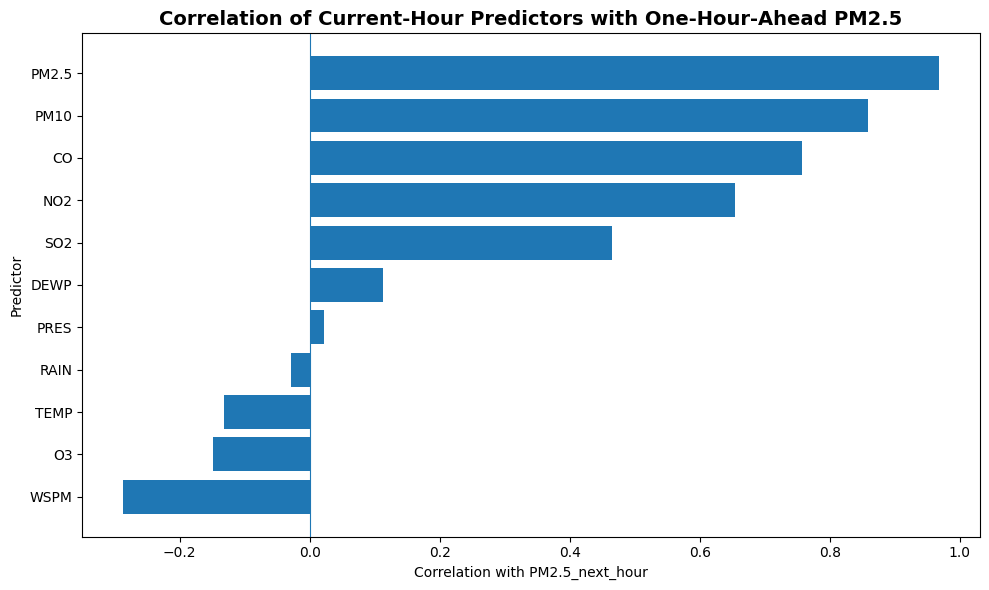

In [39]:
# ============================================================
# Correlation Plot
# ============================================================

import matplotlib.pyplot as plt

# Sort correlations so lowest appears at the bottom
plot_corr = forecast_corr.sort_values()

plt.figure(figsize=(10, 6))                                # Set figure size

plt.barh(                                                  # Horizontal bar chart
    plot_corr.index,                                       # Predictor names on y-axis
    plot_corr.values                                       # Correlation values on x-axis
)

# Add chart title and axis labels
plt.title(
    'Correlation of Current-Hour Predictors with One-Hour-Ahead PM2.5',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Correlation with PM2.5_next_hour')             # Label x-axis
plt.ylabel('Predictor')                                    # Label y-axis

plt.axvline(0, linewidth=0.8)                              # Reference line at zero correlation

plt.tight_layout()                                         # Optimize spacing
plt.show()                                                 # Display plot


### **Interpretation:**

* The bar chart visually confirms that **current-hour PM2.5** has the strongest positive correlation with **one-hour-ahead PM2.5 (r = 0.968)**, indicating strong short-term persistence in PM2.5 concentrations.

* **PM10 (r = 0.859)** and **CO (r = 0.758)** also show strong positive correlations with the forecasting target, followed by **NO₂ (r = 0.654)** and **SO₂ (r = 0.465)**.

* The meteorological variables exhibit comparatively weaker relationships with one-hour-ahead PM2.5. **WSPM (r = -0.287)** shows the strongest negative correlation among these variables.

### **Overall Observation**

* The visualization indicates that **current pollutant concentrations, particularly current-hour PM2.5, are more strongly associated with next-hour PM2.5 than the individual meteorological variables**.

* These results support the use of current-hour pollutant and meteorological information as predictors in the **one-hour-ahead PM2.5 forecasting models**.

#### **Correlation Between Current-Hour and One-Hour-Ahead PM2.5**

In [40]:
# ============================================================
# Current PM2.5 vs One-Hour-Ahead PM2.5
# ============================================================

# Calculate correlation between current-hour PM2.5 and next-hour PM2.5
current_next_corr = df_forecast[
    ['PM2.5', 'PM2.5_next_hour']                            # Select relevant columns
].corr().iloc[0, 1]                                         # Extract correlation coefficient

# Display result with formatting
print(
    f"Correlation between current-hour PM2.5 "
    f"and one-hour-ahead PM2.5: {current_next_corr:.4f}"    # Format to 4 decimal places
)


Correlation between current-hour PM2.5 and one-hour-ahead PM2.5: 0.9683


### **Interpretation:**

* The correlation between **current-hour PM2.5** and **one-hour-ahead PM2.5** is **0.9683**, indicating a **very strong positive linear relationship**.

* This strong correlation demonstrates substantial **hour-to-hour persistence in PM2.5 concentrations**, making current-hour PM2.5 an important predictor for one-hour-ahead forecasting.

## **6.2 Feature Selection**

* For the **one-hour-ahead PM2.5 forecasting task**, **PM2.5_next_hour** was defined as the target variable. The predictor variables consisted of environmental, meteorological, temporal, and location-related information available at the current hour **(t)**.

Current-hour **PM2.5** was retained as a predictor because it is available at the time the forecast is made and provides relevant information for predicting PM2.5 concentration one hour ahead **(t+1)**. The record identifier (**No**) and the constructed **datetime** variable were excluded from the predictor set.

In [41]:
# ============================================================
# Feature Selection for One-Hour-Ahead PM2.5 Forecasting
# ============================================================

# Target variable: PM2.5 concentration one hour ahead
y = df_forecast['PM2.5_next_hour'].copy()                   # Define target (dependent variable)

# Predictor variables: information available at the current hour
# Exclude target, record identifier, and helper time-verification variables
X = df_forecast.drop(                                       # Define predictors (independent variables)
    columns=[
        'PM2.5_next_hour',                                  # Target variable
        'datetime',                                         # Current timestamp
        'next_datetime',                                    # Next timestamp
        'time_gap',                                         # Helper column for time difference
        'No'                                                # Record identifier
    ]
).copy()

# Display dimensions of predictors and target
print("Predictor Variables Shape:", X.shape)                # Show dimensions of X (rows × features)
print("Target Variable Shape:", y.shape)                    # Show dimensions of y (rows,)

# Preview predictors and target
display(X.head())                                           # Preview first 5 rows of predictors
display(y.head())                                           # Preview first 5 values of target


Predictor Variables Shape: (420734, 17)
Target Variable Shape: (420734,)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


,PM2.5_next_hour
0,8.0
1,7.0
2,6.0
3,3.0
4,5.0


### **Interpretation:**

#### **Predictor and Target Variable Definition**

* Following preprocessing and construction of the one-hour-ahead forecasting target, the **final forecasting dataset contains 420,734 observations**, with **17 predictor variables** and one target variable used for model development.

* The predictor variables include **air pollutant concentrations, meteorological conditions, temporal variables, wind direction, and monitoring-station information** available at the current observation time.

* The target variable, **PM2.5_next_hour**, represents the PM2.5 concentration **one hour after the current observation**.

* The displayed observations confirm the correct temporal alignment between the predictors and the forecasting target. For example, predictors recorded at **00:00** are associated with the PM2.5 concentration observed at **01:00** as the prediction target.

### **Overall Observation**

* The predictor and target variables are correctly structured for **supervised machine learning**, with current-hour information used to forecast PM2.5 concentration **one hour ahead**.

* The forecasting target is kept separate from the predictor variables, preventing **direct target leakage** during model development.

## **6.3 Encode Categorical Variables**

In [42]:
# ============================================================
# One-Hot Encoding of Categorical Variables
# ============================================================

X = pd.get_dummies(                          # Apply one-hot encoding
    X,                                       # DataFrame of predictors
    columns=['station', 'wd'],               # Encode categorical columns: station, wind direction
    drop_first=True                          # Drop first category to avoid dummy variable trap
)

print("Shape after encoding:", X.shape)      # Show new shape after encoding (rows × features)

display(X.head())                            # Preview first 5 rows of encoded predictors


Shape after encoding: (420734, 41)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,station_Changping,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong,wd_ENE,wd_ESE,wd_N,wd_NE,wd_NNE,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


### **Interpretation:**

#### **Encoding of Categorical Variables**

* The categorical predictor variables **station** and **wind direction (wd)** were transformed into numerical dummy variables so that they could be used by the machine learning algorithms.

* Following encoding, the predictor dataset contains **420,734 observations and 41 predictor variables**. The number of observations remained unchanged, confirming that the encoding process modified only the representation of the categorical variables and did not remove any records.

* The original **station** and **wd** categorical variables were replaced by their corresponding binary indicator variables, while the existing numerical predictor variables were retained.

* One category from each categorical variable was omitted as the **reference category**, avoiding redundant dummy variables and reducing perfect multicollinearity among the encoded categories.

### **Overall Observation**

* The encoding process successfully converted all categorical predictors into a numerical format suitable for machine learning while preserving all **420,734 forecasting observations**.

* The resulting dataset with **41 predictor variables** is ready for chronological training and testing dataset preparation.

## **6.4 Time-Based Train-Test Split**

* To provide a realistic evaluation of one-hour-ahead PM2.5 forecasting, the dataset was divided chronologically rather than randomly. The earlier 80% of observations were used for model training, while the most recent 20% were reserved for testing. This approach ensures that the models are trained using past observations and evaluated on future observations, thereby reducing the risk of temporal data leakage.

In [43]:
# ============================================================
# Time-Based Train-Test Split
# ============================================================

# Create chronological order using the original datetime information
time_order = df_forecast.sort_values(                 # Sort rows chronologically
    by=['datetime', 'station']                        # Order by datetime first, then station
).index                                               # Get sorted index

# Reorder predictors, target, and datetime consistently
X_time = X.loc[time_order].reset_index(drop=True)     # Apply sorted order to predictors
y_time = y.loc[time_order].reset_index(drop=True)     # Apply sorted order to target
datetime_time = (                                     # Extract datetime column in same order
    df_forecast.loc[time_order, 'datetime']
    .reset_index(drop=True)
)

# Find approximate 80% split point
approx_split = int(len(X_time) * 0.80)                # Calculate index for 80% cutoff

# Use the timestamp at the approximate 80% point as the cutoff
cutoff_time = datetime_time.iloc[approx_split]        # Get datetime at cutoff index

# Keep complete timestamps together
train_mask = datetime_time < cutoff_time              # Training mask → rows before cutoff
test_mask = datetime_time >= cutoff_time              # Testing mask → rows at/after cutoff

X_train = X_time.loc[train_mask].reset_index(drop=True)  # Training predictors
y_train = y_time.loc[train_mask].reset_index(drop=True)  # Training target

X_test = X_time.loc[test_mask].reset_index(drop=True)    # Testing predictors
y_test = y_time.loc[test_mask].reset_index(drop=True)    # Testing target

print("Training set shape:", X_train.shape)           # Print training set shape
print("Testing set shape:", X_test.shape)             # Print testing set shape

print("\nTraining period:")                           # Print training period range
print(datetime_time.loc[train_mask].min(), "to",      # First training timestamp
      datetime_time.loc[train_mask].max())            # Last training timestamp

print("\nTesting period:")                            # Print testing period range
print(datetime_time.loc[test_mask].min(), "to",       # First testing timestamp
      datetime_time.loc[test_mask].max())             # Last testing timestamp

print("\nForecasting horizon: 1 hour ahead")          # State forecasting horizon
print("Cutoff time:", cutoff_time)                    # Print cutoff timestamp


Training set shape: (336578, 41)
Testing set shape: (84156, 41)

Training period:
2013-03-01 00:00:00 to 2016-05-12 17:00:00

Testing period:
2016-05-12 18:00:00 to 2017-02-28 22:00:00

Forecasting horizon: 1 hour ahead
Cutoff time: 2016-05-12 18:00:00


### **Interpretation:**

#### **Chronological Train-Test Split**

* The forecasting dataset was divided chronologically into **training and testing sets**, preserving the temporal order of the observations.

* The training set contains **336,578 observations with 41 predictor variables**, while the testing set contains **84,156 observations with the same 41 predictors**, corresponding to approximately an **80:20 chronological split**.

* The training period extends from **1 March 2013 at 00:00** to **12 May 2016 at 17:00**, while the testing period begins at the cutoff time of **12 May 2016 at 18:00** and extends to **28 February 2017 at 22:00**.

* This chronological approach ensures that the models are trained using earlier observations and evaluated using later, unseen observations, which is appropriate for the **one-hour-ahead forecasting objective**.

#### **Forecasting Horizon**

* The forecasting horizon is explicitly defined as **one hour ahead**, meaning that predictor information available at the current observation time is used to predict the PM2.5 concentration at the subsequent hour.

### **Overall Observation**

* The chronological train-test split provides a realistic evaluation framework for assessing how effectively the machine learning models generalize to future unseen observations while avoiding the use of future observations to train models evaluated on earlier periods.

### **6.4.1 Evaluation Metrics**

* **Mean Absolute Error (MAE)** measures the average absolute difference between the predicted and actual PM2.5 concentrations. In practical terms, it represents the average forecasting error in **µg/m³**, making it directly interpretable for air-quality monitoring.

* **Root Mean Squared Error (RMSE)** gives greater weight to larger forecasting errors. This is particularly relevant for air-quality forecasting because large prediction errors during elevated pollution episodes may have greater operational significance for monitoring and early-warning applications.

* **Coefficient of Determination (R²)** measures the proportion of variation in one-hour-ahead PM2.5 concentrations explained by the model. Higher R² values indicate stronger overall predictive performance; however, R² is interpreted together with MAE and RMSE when comparing models.

* Model performance was therefore evaluated using all three metrics to balance **overall predictive performance, typical forecasting error, and sensitivity to larger prediction errors**.

## **6.5 Model Building**

### **6.5.1 Linear Regression**

* **Linear Regression** was selected as the **baseline model** for one-hour-ahead PM2.5 forecasting. It provides a simple and interpretable benchmark for comparing the performance of more advanced machine learning models.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.

In [44]:
from sklearn.linear_model import LinearRegression            # Import Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np                                           # NumPy for math functions

# Initialize and train Linear Regression
lr_model = LinearRegression()                                # Create Linear Regression instance
lr_model.fit(X_train, y_train)                               # Fit model on training data

# Predictions on training and testing data
y_train_pred_lr = lr_model.predict(X_train)                  # Predict on training set
y_test_pred_lr = lr_model.predict(X_test)                    # Predict on testing set

# Training metrics
lr_train_mae = mean_absolute_error(y_train, y_train_pred_lr) # Mean Absolute Error (train)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr)) # RMSE (train)
lr_train_r2 = r2_score(y_train, y_train_pred_lr)             # R² score (train)

# Testing metrics
lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)    # Mean Absolute Error (test)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))    # RMSE (test)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)                # R² score (test)

# Display results
print("LINEAR REGRESSION PERFORMANCE")                       # Section header
print("=" * 45)

print("\nTraining Performance")                              # Training results header
print(f"MAE  : {lr_train_mae:.2f}")                          # Print MAE (2 decimals)
print(f"RMSE : {lr_train_rmse:.2f}")                         # Print RMSE (2 decimals)
print(f"R²   : {lr_train_r2:.4f}")                           # Print R² (4 decimals)

print("\nTesting Performance")                               # Testing results header
print(f"MAE  : {lr_test_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {lr_test_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {lr_test_r2:.4f}")                            # Print R² (4 decimals)


LINEAR REGRESSION PERFORMANCE

Training Performance
MAE  : 10.81
RMSE : 20.06
R²   : 0.9382

Testing Performance
MAE  : 10.16
RMSE : 19.13
R²   : 0.9477


### **Interpretation:**

#### **Linear Regression Performance**

* The Linear Regression model demonstrated strong predictive performance for **one-hour-ahead PM2.5 forecasting**.

* On the training dataset, the model achieved an **MAE of 10.81 µg/m³**, an **RMSE of 20.06 µg/m³**, and an **R² of 0.9382**. This indicates that the model explained approximately **93.82% of the variation** in one-hour-ahead PM2.5 concentrations within the training period.

* On the chronological testing dataset, the model achieved an **MAE of 10.16 µg/m³**, an **RMSE of 19.13 µg/m³**, and an **R² of 0.9477**, explaining approximately **94.77% of the variation** in PM2.5 concentrations during the unseen testing period.

### **Overall Observation**

* The testing MAE and RMSE are slightly lower than the corresponding training errors, while the testing R² is slightly higher than the training R².

* The similarity between training and testing performance indicates that the Linear Regression model **generalizes well to the unseen chronological testing period**, with no evidence of substantial overfitting based on these performance metrics.

* The final selection of the best-performing model will be determined after comparing these results with the performance of the other machine learning models.

### **6.5.2 Decision Tree Regressor**

* **Decision Tree Regressor** was developed to capture the **non-linear relationships** between the predictor variables and one-hour-ahead PM2.5 concentrations. Unlike Linear Regression, Decision Trees can learn complex patterns and interactions between variables without assuming a linear relationship.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.

In [45]:
from sklearn.tree import DecisionTreeRegressor              # Import Decision Tree Regressor

# Initialize and train Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)           # Create Decision Tree instance (fixed seed)
dt_model.fit(X_train, y_train)                              # Fit model on training data

# Predictions on training and testing data
y_train_pred_dt = dt_model.predict(X_train)                 # Predict on training set
y_test_pred_dt = dt_model.predict(X_test)                   # Predict on testing set

# Training metrics
dt_train_mae = mean_absolute_error(y_train, y_train_pred_dt) # Mean Absolute Error (train)
dt_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_dt)) # RMSE (train)
dt_train_r2 = r2_score(y_train, y_train_pred_dt)             # R² score (train)

# Testing metrics
dt_test_mae = mean_absolute_error(y_test, y_test_pred_dt)    # Mean Absolute Error (test)
dt_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))    # RMSE (test)
dt_test_r2 = r2_score(y_test, y_test_pred_dt)                # R² score (test)

# Display results
print("DECISION TREE PERFORMANCE")                           # Section header
print("=" * 45)

print("\nTraining Performance")                              # Training results header
print(f"MAE  : {dt_train_mae:.2f}")                          # Print MAE (2 decimals)
print(f"RMSE : {dt_train_rmse:.2f}")                         # Print RMSE (2 decimals)
print(f"R²   : {dt_train_r2:.4f}")                           # Print R² (4 decimals)

print("\nTesting Performance")                               # Testing results header
print(f"MAE  : {dt_test_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {dt_test_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {dt_test_r2:.4f}")                            # Print R² (4 decimals)


DECISION TREE PERFORMANCE

Training Performance
MAE  : 0.00
RMSE : 0.00
R²   : 1.0000

Testing Performance
MAE  : 16.88
RMSE : 31.78
R²   : 0.8558


### **Interpretation:**

#### **Decision Tree Performance**

* The Decision Tree model achieved a **perfect fit on the training dataset**, with an **MAE of 0.00 µg/m³**, an **RMSE of 0.00 µg/m³**, and an **R² of 1.0000**.

* However, performance declined considerably on the chronological testing dataset, where the model achieved an **MAE of 16.88 µg/m³**, an **RMSE of 31.78 µg/m³**, and an **R² of 0.8558**.

* The testing R² indicates that the model explained approximately **85.58% of the variation** in one-hour-ahead PM2.5 concentrations during the unseen testing period.

### **Overall Observation**

* The substantial difference between the perfect training performance and the lower testing performance indicates that the Decision Tree model **overfits the training data**.

* Although the model captures the training observations extremely well, its higher testing errors and lower testing R² demonstrate **weaker generalization to future unseen observations**.

* The Decision Tree results will therefore be compared with the other machine learning models before selecting the final best-performing model.

### **6.5.3 Random Forest Regressor**

* **Random Forest Regressor** was developed as an **ensemble learning model** that combines multiple decision trees to improve predictive performance and reduce the overfitting associated with a single Decision Tree.

* Each tree is trained using random samples of the training observations and predictor variables, and the final regression prediction is obtained by **averaging the predictions across the individual trees**.

* The model was trained using **earlier chronological training observations** to forecast PM2.5 concentration one hour ahead and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.

In [46]:
from sklearn.ensemble import RandomForestRegressor          # Import Random Forest Regressor

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(                           # Create Random Forest instance
    n_estimators=100,                                       # Number of trees in the forest
    random_state=42,                                        # Fixed seed for reproducibility
    n_jobs=-1                                               # Use all CPU cores for faster training
)

# Train the model
rf_model.fit(X_train, y_train)                              # Fit model on training data

# Predictions on training and testing data
y_train_pred_rf = rf_model.predict(X_train)                 # Predict on training set
y_test_pred_rf = rf_model.predict(X_test)                   # Predict on testing set

# Training metrics
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf) # Mean Absolute Error (train)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf)) # RMSE (train)
rf_train_r2 = r2_score(y_train, y_train_pred_rf)             # R² score (train)

# Testing metrics
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)    # Mean Absolute Error (test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))    # RMSE (test)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)                # R² score (test)

# Display results
print("RANDOM FOREST PERFORMANCE")                           # Section header
print("=" * 45)

print("\nTraining Performance")                              # Training results header
print(f"MAE  : {rf_train_mae:.2f}")                          # Print MAE (2 decimals)
print(f"RMSE : {rf_train_rmse:.2f}")                         # Print RMSE (2 decimals)
print(f"R²   : {rf_train_r2:.4f}")                           # Print R² (4 decimals)

print("\nTesting Performance")                               # Testing results header
print(f"MAE  : {rf_test_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {rf_test_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {rf_test_r2:.4f}")                            # Print R² (4 decimals)


RANDOM FOREST PERFORMANCE

Training Performance
MAE  : 3.72
RMSE : 7.03
R²   : 0.9924

Testing Performance
MAE  : 10.40
RMSE : 20.61
R²   : 0.9394


### **Interpretation:**

#### **Random Forest Performance**

* The Random Forest Regressor demonstrated strong predictive performance for **one-hour-ahead PM2.5 forecasting**.

* On the training dataset, the model achieved an **MAE of 3.72 µg/m³**, an **RMSE of 7.03 µg/m³**, and an **R² of 0.9924**, indicating an extremely strong fit to the training observations.

* On the chronological testing dataset, the model achieved an **MAE of 10.40 µg/m³**, an **RMSE of 20.61 µg/m³**, and an **R² of 0.9394**, explaining approximately **93.94% of the variation** in one-hour-ahead PM2.5 concentrations during the unseen testing period.

### **Overall Observation**

* The Random Forest model achieved substantially better performance on the training dataset than on the testing dataset, indicating a degree of **overfitting**.

* Despite this train-test performance gap, the model retained strong predictive performance on the unseen chronological testing period.

* The Random Forest results will be compared with the other machine learning models before selecting the final best-performing model.

### **6.5.4 XGBoost Regression**

* **XGBoost (Extreme Gradient Boosting)** was developed as an advanced ensemble learning model for one-hour-ahead PM2.5 forecasting.

* Unlike Random Forest, which builds multiple decision trees independently, XGBoost builds trees sequentially, with each new tree learning from the prediction errors of the preceding ensemble. This enables the model to capture **complex non-linear relationships** between the predictor variables and future PM2.5 concentrations.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.

In [47]:
from xgboost import XGBRegressor                           # Import XGBoost Regressor

# Initialize XGBoost Regressor
xgb_model = XGBRegressor(                                  # Create XGBoost instance
    n_estimators=100,                                      # Number of boosting rounds (trees)
    learning_rate=0.1,                                     # Step size shrinkage
    max_depth=6,                                           # Maximum depth of each tree
    random_state=42,                                       # Fixed seed for reproducibility
    tree_method='hist',                                    # Fast histogram-based algorithm
    device='cuda'                                          # Use GPU acceleration (CUDA)
)

# Train the model
xgb_model.fit(X_train, y_train)                            # Fit model on training data

# Predictions on training and testing data
y_train_pred_xgb = xgb_model.predict(X_train)              # Predict on training set
y_test_pred_xgb = xgb_model.predict(X_test)                # Predict on testing set

# Training metrics
xgb_train_mae = mean_absolute_error(y_train, y_train_pred_xgb) # Mean Absolute Error (train)
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)) # RMSE (train)
xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)         # R² score (train)

# Testing metrics
xgb_test_mae = mean_absolute_error(y_test, y_test_pred_xgb)    # Mean Absolute Error (test)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))    # RMSE (test)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)                # R² score (test)

# Display results
print("XGBOOST REGRESSOR PERFORMANCE")                    # Section header
print("=" * 45)

print("\nTraining Performance")                           # Training results header
print(f"MAE  : {xgb_train_mae:.2f}")                      # Print MAE (2 decimals)
print(f"RMSE : {xgb_train_rmse:.2f}")                     # Print RMSE (2 decimals)
print(f"R²   : {xgb_train_r2:.4f}")                       # Print R² (4 decimals)

print("\nTesting Performance")                            # Testing results header
print(f"MAE  : {xgb_test_mae:.2f}")                       # Print MAE (2 decimals)
print(f"RMSE : {xgb_test_rmse:.2f}")                      # Print RMSE (2 decimals)
print(f"R²   : {xgb_test_r2:.4f}")                        # Print R² (4 decimals)


XGBOOST REGRESSOR PERFORMANCE

Training Performance
MAE  : 9.79
RMSE : 17.50
R²   : 0.9530

Testing Performance
MAE  : 9.96
RMSE : 19.91
R²   : 0.9434


### **Interpretation:**

#### **XGBoost Performance**

* The XGBoost Regressor demonstrated strong predictive performance for **one-hour-ahead PM2.5 forecasting**.

* On the training dataset, the model achieved an **MAE of 9.79 µg/m³**, an **RMSE of 17.50 µg/m³**, and an **R² of 0.9530**.

* On the chronological testing dataset, the model achieved an **MAE of 9.96 µg/m³**, an **RMSE of 19.91 µg/m³**, and an **R² of 0.9434**, explaining approximately **94.34% of the variation** in one-hour-ahead PM2.5 concentrations during the unseen testing period.

### **Overall Observation**

* The training and testing performance metrics are relatively close, indicating that the XGBoost model **generalizes well to the unseen chronological testing period**.

* The slightly higher testing errors and slightly lower testing R² compared with the training results indicate a modest reduction in performance on unseen data, without evidence of substantial overfitting.

* The XGBoost results will be compared with the other machine learning models before selecting the final best-performing model.

### **6.5.5 Gradient Boosting Regressor**

* **Gradient Boosting Regressor** was implemented as an ensemble learning algorithm that sequentially builds decision trees, with each new tree learning to correct the prediction errors made by the preceding ensemble.

* By combining multiple weak learners, the model can capture **complex non-linear relationships** between the predictor variables and one-hour-ahead PM2.5 concentrations.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.

In [48]:
from sklearn.ensemble import GradientBoostingRegressor       # Import Gradient Boosting Regressor

# Initialize Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(                        # Create Gradient Boosting instance
    n_estimators=100,                                        # Number of boosting stages (trees)
    random_state=42                                          # Fixed seed for reproducibility
)

# Train the model
gb_model.fit(X_train, y_train)                               # Fit model on training data

# Predictions on training and testing data
y_train_pred_gb = gb_model.predict(X_train)                  # Predict on training set
y_test_pred_gb = gb_model.predict(X_test)                    # Predict on testing set

# Training metrics
gb_train_mae = mean_absolute_error(y_train, y_train_pred_gb) # Mean Absolute Error (train)
gb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_gb)) # RMSE (train)
gb_train_r2 = r2_score(y_train, y_train_pred_gb)             # R² score (train)

# Testing metrics
gb_test_mae = mean_absolute_error(y_test, y_test_pred_gb)    # Mean Absolute Error (test)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))    # RMSE (test)
gb_test_r2 = r2_score(y_test, y_test_pred_gb)                # R² score (test)

# Display results
print("GRADIENT BOOSTING PERFORMANCE")                       # Section header
print("=" * 45)

print("\nTraining Performance")                              # Training results header
print(f"MAE  : {gb_train_mae:.2f}")                          # Print MAE (2 decimals)
print(f"RMSE : {gb_train_rmse:.2f}")                         # Print RMSE (2 decimals)
print(f"R²   : {gb_train_r2:.4f}")                           # Print R² (4 decimals)

print("\nTesting Performance")                               # Testing results header
print(f"MAE  : {gb_test_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {gb_test_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {gb_test_r2:.4f}")                            # Print R² (4 decimals)


GRADIENT BOOSTING PERFORMANCE

Training Performance
MAE  : 10.31
RMSE : 19.07
R²   : 0.9441

Testing Performance
MAE  : 9.91
RMSE : 19.48
R²   : 0.9458


### **Interpretation:**

#### **Gradient Boosting Performance**

* The Gradient Boosting Regressor demonstrated strong predictive performance for **one-hour-ahead PM2.5 forecasting**.

* On the training dataset, the model achieved an **MAE of 10.31 µg/m³**, an **RMSE of 19.07 µg/m³**, and an **R² of 0.9441**.

* On the chronological testing dataset, the model achieved an **MAE of 9.91 µg/m³**, an **RMSE of 19.48 µg/m³**, and an **R² of 0.9458**, explaining approximately **94.58% of the variation** in one-hour-ahead PM2.5 concentrations during the unseen testing period.

### **Overall Observation**

* The training and testing performance metrics are very similar, indicating that the Gradient Boosting model **generalizes well to the unseen chronological testing period**.

* The testing MAE is slightly lower than the training MAE, while the RMSE is slightly higher and the R² is very similar across the two datasets. Overall, the results show **no evidence of substantial overfitting** based on these performance metrics.

* The Gradient Boosting results will be compared with the other machine learning models before selecting the final best-performing model.

### **6.5.6 AdaBoost Regressor**

* **AdaBoost Regressor (Adaptive Boosting)** was implemented as an ensemble learning model for one-hour-ahead PM2.5 forecasting.

* AdaBoost builds a sequence of weak learners, with each successive model placing greater emphasis on observations that were predicted less accurately by the preceding models. This iterative approach allows the model to progressively improve its predictions.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.

In [49]:

from sklearn.ensemble import AdaBoostRegressor              # Import AdaBoost Regressor

# Initialize AdaBoost Regressor
ada_model = AdaBoostRegressor(                              # Create AdaBoost instance
    n_estimators=100,                                       # Number of boosting stages (weak learners)
    learning_rate=0.1,                                      # Weight applied to each learner
    random_state=42                                         # Fixed seed for reproducibility
)

# Train the model
ada_model.fit(X_train, y_train)                             # Fit model on training data

# Predictions on training and testing data
y_train_pred_ada = ada_model.predict(X_train)               # Predict on training set
y_test_pred_ada = ada_model.predict(X_test)                 # Predict on testing set

# Training metrics
ada_train_mae = mean_absolute_error(y_train, y_train_pred_ada) # Mean Absolute Error (train)
ada_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ada)) # RMSE (train)
ada_train_r2 = r2_score(y_train, y_train_pred_ada)          # R² score (train)

# Testing metrics
ada_test_mae = mean_absolute_error(y_test, y_test_pred_ada) # Mean Absolute Error (test)
ada_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ada)) # RMSE (test)
ada_test_r2 = r2_score(y_test, y_test_pred_ada)             # R² score (test)

# Display results
print("ADABOOST REGRESSOR PERFORMANCE")                     # Section header
print("=" * 45)

print("\nTraining Performance")                             # Training results header
print(f"MAE  : {ada_train_mae:.2f}")                        # Print MAE (2 decimals)
print(f"RMSE : {ada_train_rmse:.2f}")                       # Print RMSE (2 decimals)
print(f"R²   : {ada_train_r2:.4f}")                         # Print R² (4 decimals)

print("\nTesting Performance")                              # Testing results header
print(f"MAE  : {ada_test_mae:.2f}")                         # Print MAE (2 decimals)
print(f"RMSE : {ada_test_rmse:.2f}")                        # Print RMSE (2 decimals)
print(f"R²   : {ada_test_r2:.4f}")                          # Print R² (4 decimals)


ADABOOST REGRESSOR PERFORMANCE

Training Performance
MAE  : 23.06
RMSE : 30.70
R²   : 0.8552

Testing Performance
MAE  : 22.77
RMSE : 30.58
R²   : 0.8665


### **Interpretation:**

#### **AdaBoost Performance**

* The AdaBoost Regressor achieved an **MAE of 23.06 µg/m³**, an **RMSE of 30.70 µg/m³**, and an **R² of 0.8552** on the training dataset.

* On the chronological testing dataset, the model achieved an **MAE of 22.77 µg/m³**, an **RMSE of 30.58 µg/m³**, and an **R² of 0.8665**, explaining approximately **86.65% of the variation** in one-hour-ahead PM2.5 concentrations during the unseen testing period.

### **Overall Observation**

* The training and testing metrics are relatively similar, indicating that the AdaBoost model **generalizes consistently to the unseen chronological testing period**.

* However, its comparatively higher MAE and RMSE and lower R² indicate weaker predictive performance than several of the models evaluated so far.

* The AdaBoost results will be included in the consolidated model comparison before selecting the final best-performing model.

### **6.5.7 LightGBM Regressor**

* **LightGBM (Light Gradient Boosting Machine) Regressor** was implemented as an efficient gradient boosting model for one-hour-ahead PM2.5 forecasting.

* LightGBM uses a **leaf-wise tree growth strategy**, enabling it to efficiently capture complex non-linear relationships within large datasets.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.

In [50]:

!pip install lightgbm -q

from lightgbm import LGBMRegressor                          # Import LightGBM Regressor

# Initialize LightGBM Regressor
lgbm_model = LGBMRegressor(                                 # Create LightGBM instance
    n_estimators=100,                                       # Number of boosting iterations (trees)
    learning_rate=0.1,                                      # Step size shrinkage
    random_state=42,                                        # Fixed seed for reproducibility
    verbosity=-1                                            # Suppress training logs
)

# Train the model
lgbm_model.fit(X_train, y_train)                            # Fit model on training data

# Predictions
y_train_pred_lgbm = lgbm_model.predict(X_train)             # Predict on training set
y_test_pred_lgbm = lgbm_model.predict(X_test)               # Predict on testing set

# Training metrics
lgbm_train_mae = mean_absolute_error(y_train, y_train_pred_lgbm) # Mean Absolute Error (train)
lgbm_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lgbm)) # RMSE (train)
lgbm_train_r2 = r2_score(y_train, y_train_pred_lgbm)        # R² score (train)

# Testing metrics
lgbm_test_mae = mean_absolute_error(y_test, y_test_pred_lgbm) # Mean Absolute Error (test)
lgbm_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lgbm)) # RMSE (test)
lgbm_test_r2 = r2_score(y_test, y_test_pred_lgbm)           # R² score (test)

# Display results
print("LIGHTGBM REGRESSOR PERFORMANCE")                     # Section header
print("=" * 45)

print("\nTraining Performance")                             # Training results header
print(f"MAE  : {lgbm_train_mae:.2f}")                       # Print MAE (2 decimals)
print(f"RMSE : {lgbm_train_rmse:.2f}")                      # Print RMSE (2 decimals)
print(f"R²   : {lgbm_train_r2:.4f}")                        # Print R² (4 decimals)

print("\nTesting Performance")                              # Testing results header
print(f"MAE  : {lgbm_test_mae:.2f}")                        # Print MAE (2 decimals)
print(f"RMSE : {lgbm_test_rmse:.2f}")                       # Print RMSE (2 decimals)
print(f"R²   : {lgbm_test_r2:.4f}")                         # Print R² (4 decimals)


LIGHTGBM REGRESSOR PERFORMANCE

Training Performance
MAE  : 9.87
RMSE : 17.79
R²   : 0.9514

Testing Performance
MAE  : 9.85
RMSE : 19.60
R²   : 0.9452


### **Interpretation:**

#### **LightGBM Performance**

* The LightGBM Regressor demonstrated strong predictive performance for **one-hour-ahead PM2.5 forecasting**.

* On the training dataset, the model achieved an **MAE of 9.87 µg/m³**, an **RMSE of 17.79 µg/m³**, and an **R² of 0.9514**.

* On the chronological testing dataset, the model achieved an **MAE of 9.85 µg/m³**, an **RMSE of 19.60 µg/m³**, and an **R² of 0.9452**, explaining approximately **94.52% of the variation** in one-hour-ahead PM2.5 concentrations during the unseen testing period.

### **Overall Observation**

* The training and testing results are relatively close, indicating that the LightGBM model **generalizes well to the unseen chronological testing period**.

* The testing MAE is almost identical to the training MAE, while the testing RMSE is moderately higher and the testing R² is slightly lower. Overall, the results show **no evidence of substantial overfitting** based on these performance metrics.

* The LightGBM results will be compared with the other machine learning models before selecting the final best-performing model.

### **6.5.8 CatBoost Regressor**

* **CatBoost (Categorical Boosting) Regressor** was implemented as an advanced gradient boosting model for one-hour-ahead PM2.5 forecasting.

* CatBoost builds decision trees sequentially and uses an ordered boosting approach designed to improve generalization and reduce prediction bias during model training.

* The model was trained using **earlier chronological training observations** and evaluated on the later, unseen testing period.

* Performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)** for both the training and testing datasets.

In [51]:
!pip install catboost -q
from catboost import CatBoostRegressor                      # Import CatBoost Regressor

# Initialize CatBoost Regressor
cat_model = CatBoostRegressor(                              # Create CatBoost instance
    iterations=100,                                         # Number of boosting iterations (trees)
    learning_rate=0.1,                                      # Step size shrinkage
    depth=6,                                                # Maximum depth of each tree
    random_seed=42,                                         # Fixed seed for reproducibility
    verbose=0,                                              # Suppress training logs
    task_type='GPU'                                         # Use GPU acceleration if available
)

# Train the model
cat_model.fit(X_train, y_train)                             # Fit model on training data

# Predictions on training and testing data
y_train_pred_cat = cat_model.predict(X_train)               # Predict on training set
y_test_pred_cat = cat_model.predict(X_test)                 # Predict on testing set

# Training metrics
cat_train_mae = mean_absolute_error(y_train, y_train_pred_cat) # Mean Absolute Error (train)
cat_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_cat)) # RMSE (train)
cat_train_r2 = r2_score(y_train, y_train_pred_cat)          # R² score (train)

# Testing metrics
cat_test_mae = mean_absolute_error(y_test, y_test_pred_cat) # Mean Absolute Error (test)
cat_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_cat)) # RMSE (test)
cat_test_r2 = r2_score(y_test, y_test_pred_cat)             # R² score (test)

# Display results
print("CATBOOST REGRESSOR PERFORMANCE")                     # Section header
print("=" * 45)

print("\nTraining Performance")                             # Training results header
print(f"MAE  : {cat_train_mae:.2f}")                        # Print MAE (2 decimals)
print(f"RMSE : {cat_train_rmse:.2f}")                       # Print RMSE (2 decimals)
print(f"R²   : {cat_train_r2:.4f}")                         # Print R² (4 decimals)

print("\nTesting Performance")                              # Testing results header
print(f"MAE  : {cat_test_mae:.2f}")                         # Print MAE (2 decimals)
print(f"RMSE : {cat_test_rmse:.2f}")                        # Print RMSE (2 decimals)
print(f"R²   : {cat_test_r2:.4f}")                          # Print R² (4 decimals)


CATBOOST REGRESSOR PERFORMANCE

Training Performance
MAE  : 10.43
RMSE : 19.29
R²   : 0.9429

Testing Performance
MAE  : 10.16
RMSE : 19.94
R²   : 0.9432


### **Interpretation:**

#### **CatBoost Performance**

* The CatBoost Regressor demonstrated strong predictive performance for **one-hour-ahead PM2.5 forecasting**.

* On the training dataset, the model achieved an **MAE of 10.43 µg/m³**, an **RMSE of 19.29 µg/m³**, and an **R² of 0.9429**.

* On the chronological testing dataset, the model achieved an **MAE of 10.16 µg/m³**, an **RMSE of 19.94 µg/m³**, and an **R² of 0.9432**, explaining approximately **94.32% of the variation** in one-hour-ahead PM2.5 concentrations during the unseen testing period.

### **Overall Observation**

* The training and testing performance metrics are very similar, indicating that the CatBoost model **generalizes well to the unseen chronological testing period**.

* The testing MAE is slightly lower than the training MAE, while the testing RMSE is slightly higher and the R² values are nearly identical. These results show **no evidence of substantial overfitting** based on the reported performance metrics.

* The CatBoost results were included in the consolidated comparison with the other machine learning models.

## **6.6 Model Performance Comparison**

### **6.6.1 Consolidated Model Performance Table**

In [52]:
# ============================================================
# Create Consolidated Model Performance Table
# ============================================================

# Combine training and testing performance metrics
# from all machine learning models into one DataFrame
model_comparison = pd.DataFrame({                           # Build a DataFrame to hold all metrics

    'Model': [                                              # Column listing model names
        'Linear Regression',                                # Simple baseline model
        'Decision Tree',                                    # Tree-based model
        'Random Forest',                                    # Ensemble of decision trees
        'XGBoost',                                          # Gradient boosting with optimizations
        'Gradient Boosting',                                # Standard gradient boosting
        'AdaBoost',                                         # Adaptive boosting
        'LightGBM',                                         # Gradient boosting optimized for speed
        'CatBoost'                                          # Gradient boosting optimized for categorical features
    ],

    'Train MAE': [                                          # Training Mean Absolute Error values
        lr_train_mae,                                       # Linear Regression train MAE
        dt_train_mae,                                       # Decision Tree train MAE
        rf_train_mae,                                       # Random Forest train MAE
        xgb_train_mae,                                      # XGBoost train MAE
        gb_train_mae,                                       # Gradient Boosting train MAE
        ada_train_mae,                                      # AdaBoost train MAE
        lgbm_train_mae,                                     # LightGBM train MAE
        cat_train_mae                                       # CatBoost train MAE
    ],

    'Train RMSE': [                                         # Training Root Mean Squared Error values
        lr_train_rmse,                                      # Linear Regression train RMSE
        dt_train_rmse,                                      # Decision Tree train RMSE
        rf_train_rmse,                                      # Random Forest train RMSE
        xgb_train_rmse,                                     # XGBoost train RMSE
        gb_train_rmse,                                      # Gradient Boosting train RMSE
        ada_train_rmse,                                     # AdaBoost train RMSE
        lgbm_train_rmse,                                    # LightGBM train RMSE
        cat_train_rmse                                      # CatBoost train RMSE
    ],

    'Train R²': [                                           # Training R² scores
        lr_train_r2,                                        # Linear Regression train R²
        dt_train_r2,                                        # Decision Tree train R²
        rf_train_r2,                                        # Random Forest train R²
        xgb_train_r2,                                       # XGBoost train R²
        gb_train_r2,                                        # Gradient Boosting train R²
        ada_train_r2,                                       # AdaBoost train R²
        lgbm_train_r2,                                      # LightGBM train R²
        cat_train_r2                                        # CatBoost train R²
    ],

    'Test MAE': [                                           # Testing Mean Absolute Error values
        lr_test_mae,                                        # Linear Regression test MAE
        dt_test_mae,                                        # Decision Tree test MAE
        rf_test_mae,                                        # Random Forest test MAE
        xgb_test_mae,                                       # XGBoost test MAE
        gb_test_mae,                                        # Gradient Boosting test MAE
        ada_test_mae,                                       # AdaBoost test MAE
        lgbm_test_mae,                                      # LightGBM test MAE
        cat_test_mae                                        # CatBoost test MAE
    ],

    'Test RMSE': [                                          # Testing Root Mean Squared Error values
        lr_test_rmse,                                       # Linear Regression test RMSE
        dt_test_rmse,                                       # Decision Tree test RMSE
        rf_test_rmse,                                       # Random Forest test RMSE
        xgb_test_rmse,                                      # XGBoost test RMSE
        gb_test_rmse,                                       # Gradient Boosting test RMSE
        ada_test_rmse,                                      # AdaBoost test RMSE
        lgbm_test_rmse,                                     # LightGBM test RMSE
        cat_test_rmse                                       # CatBoost test RMSE
    ],

    'Test R²': [                                            # Testing R² scores
        lr_test_r2,                                         # Linear Regression test R²
        dt_test_r2,                                         # Decision Tree test R²
        rf_test_r2,                                         # Random Forest test R²
        xgb_test_r2,                                        # XGBoost test R²
        gb_test_r2,                                         # Gradient Boosting test R²
        ada_test_r2,                                        # AdaBoost test R²
        lgbm_test_r2,                                       # LightGBM test R²
        cat_test_r2                                         # CatBoost test R²
    ]
})

# Display the consolidated model performance table
print("Consolidated Model Performance Table:")              # Section header for clarity
display(model_comparison)                                   # Show DataFrame neatly in notebook


Consolidated Model Performance Table:


,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
0,Linear Regression,10.811007,20.064170,0.938159,10.158884,19.131428,0.947735
1,Decision Tree,0.000000,0.000000,1.000000,16.879321,31.781814,0.855765
2,Random Forest,3.716992,7.032829,0.992402,10.404214,20.607960,0.939357
3,XGBoost,9.790203,17.499893,0.952956,9.960364,19.913409,0.943376
4,Gradient Boosting,10.313888,19.073554,0.944115,9.906021,19.477059,0.945830
5,AdaBoost,23.063746,30.703963,0.855182,22.768781,30.578986,0.866476
6,LightGBM,9.869027,17.794917,0.951356,9.853680,19.595150,0.945171
7,CatBoost,10.434962,19.287315,0.942855,10.162740,19.939479,0.943227


### **Note:**
*  This table compiles the raw performance metrics from all eight models. The results are summarized and compared in Section **6.6**.

### **6.6.2 Ranked Model Performance Comparison**

In [53]:
# ============================================================
# 6.6.2 Ranked Model Performance Comparison
# ============================================================

# Remove Rank column if it exists from a previous run
if 'Rank' in model_comparison.columns:                     # Check if Rank column already exists
    model_comparison = model_comparison.drop(columns='Rank') # Drop Rank to avoid duplication

# ------------------------------------------------------------
# Sort models by Test R² for clear presentation
# Higher Test R² values appear first
# ------------------------------------------------------------

model_comparison = model_comparison.sort_values(           # Sort DataFrame rows
    by='Test R²',                                          # Use Test R² as ranking metric
    ascending=False                                        # Highest R² first
).reset_index(drop=True)                                   # Reset index after sorting

# ------------------------------------------------------------
# Round performance metrics for clear presentation
# ------------------------------------------------------------

model_comparison = model_comparison.round({                # Round metrics for readability
    'Train MAE': 2,                                        # Round Train MAE to 2 decimals
    'Train RMSE': 2,                                       # Round Train RMSE to 2 decimals
    'Train R²': 4,                                         # Round Train R² to 4 decimals
    'Test MAE': 2,                                         # Round Test MAE to 2 decimals
    'Test RMSE': 2,                                        # Round Test RMSE to 2 decimals
    'Test R²': 4                                           # Round Test R² to 4 decimals
})

# ------------------------------------------------------------
# Display consolidated model comparison table
# ------------------------------------------------------------

print("=" * 90)                                            # Print separator line
print("CONSOLIDATED MODEL PERFORMANCE COMPARISON")          # Section header
print("=" * 90)

display(model_comparison)                                  # Show DataFrame neatly in notebook


CONSOLIDATED MODEL PERFORMANCE COMPARISON


,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
0,Linear Regression,10.81,20.06,0.9382,10.16,19.13,0.9477
1,Gradient Boosting,10.31,19.07,0.9441,9.91,19.48,0.9458
2,LightGBM,9.87,17.79,0.9514,9.85,19.60,0.9452
3,XGBoost,9.79,17.50,0.9530,9.96,19.91,0.9434
4,CatBoost,10.43,19.29,0.9429,10.16,19.94,0.9432
5,Random Forest,3.72,7.03,0.9924,10.40,20.61,0.9394
6,AdaBoost,23.06,30.70,0.8552,22.77,30.58,0.8665
7,Decision Tree,0.00,0.00,1.0000,16.88,31.78,0.8558


### **Interpretation:**

#### **Overall Model Comparison**

* The eight machine learning models demonstrated varying levels of predictive performance for **one-hour-ahead PM2.5 forecasting**.

* **Linear Regression achieved the highest testing R² of 0.9477 and the lowest testing RMSE of 19.13 µg/m³**, indicating the strongest overall performance based on these two evaluation metrics.

* **LightGBM achieved the lowest testing MAE of 9.85 µg/m³**, followed closely by Gradient Boosting (9.91 µg/m³) and XGBoost (9.96 µg/m³). This indicates that LightGBM produced the smallest average absolute forecasting error.

* Gradient Boosting, LightGBM, XGBoost, and CatBoost also demonstrated strong predictive performance, with testing R² values ranging from **0.9432 to 0.9458**.

* Random Forest achieved a high testing R² of **0.9394**, but the substantial difference between its training and testing performance indicates some degree of overfitting.

* Decision Tree exhibited the clearest evidence of overfitting, achieving perfect training performance but a substantially lower testing R² of **0.8558**.

* AdaBoost produced comparatively higher prediction errors and a lower testing R² of **0.8665**, indicating weaker predictive performance than the leading models.

### **Overall Observation**

* Based on the **highest testing R² and lowest testing RMSE**, **Linear Regression emerged as the leading model overall** for one-hour-ahead PM2.5 forecasting in this study.

* However, **LightGBM achieved the lowest testing MAE**, demonstrating that no single model achieved the best result across all three evaluation metrics.

* The strong performance of Linear Regression suggests that the current-hour predictor variables contain substantial information for forecasting PM2.5 concentration one hour ahead.

### **6.6.3 Test R² Comparison**

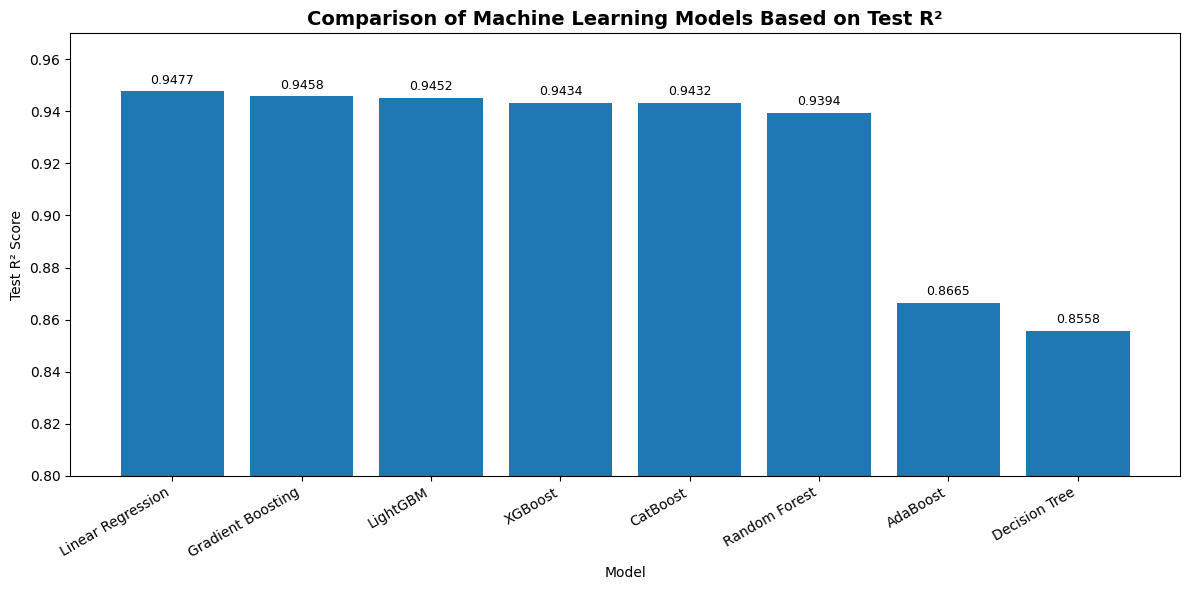

In [54]:
# ============================================================
# Test R² Comparison
# ============================================================

plt.figure(figsize=(12, 6))                                # Set figure size

bars = plt.bar(                                            # Bar chart of models vs Test R²
    model_comparison['Model'],                             # X-axis: model names
    model_comparison['Test R²']                            # Y-axis: Test R² scores
)

# Add chart title and axis labels
plt.title(
    'Comparison of Machine Learning Models Based on Test R²',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Model')                                        # Label x-axis
plt.ylabel('Test R² Score')                                # Label y-axis
plt.xticks(rotation=30, ha='right')                        # Rotate labels for readability
plt.ylim(0.80, 0.97)                                       # Set y-axis range for focus

# Display R² value above each bar
for bar, value in zip(bars, model_comparison['Test R²']):
    plt.text(
        bar.get_x() + bar.get_width()/2,                   # Center text above bar
        value + 0.003,                                     # Slightly above bar height
        f'{value:.4f}',                                    # Format to 4 decimals
        ha='center',
        fontsize=9
    )

plt.tight_layout()                                         # Optimize spacing
plt.show()                                                 # Display plot


### **Interpretation:**

* The comparison of testing R² scores shows that **Linear Regression achieved the highest Test R² of 0.9477**, indicating the strongest predictive performance based on this metric.

* Gradient Boosting (**0.9458**) and LightGBM (**0.9452**) followed closely, while XGBoost (**0.9434**), CatBoost (**0.9432**), and Random Forest (**0.9394**) also demonstrated strong predictive performance.

* AdaBoost (**0.8665**) and Decision Tree (**0.8558**) achieved comparatively lower Test R² scores than the other models.

### **Overall Observation**

* The results show that several models performed strongly for **one-hour-ahead PM2.5 forecasting**, with relatively small differences among the leading models.

* Based specifically on **Test R²**, **Linear Regression ranked first among the eight evaluated models**.

### **6.6.4 Training vs Testing R² Comparison**

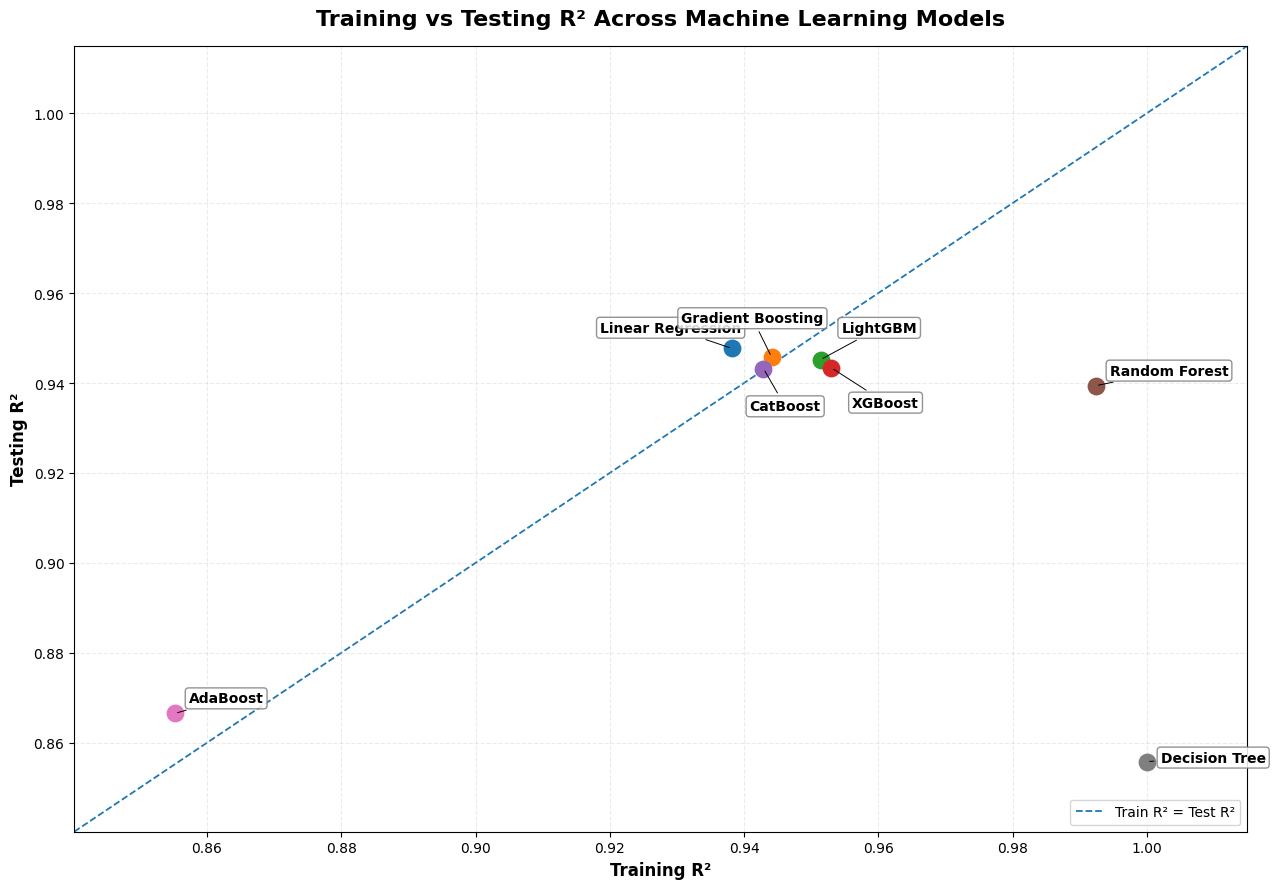

In [55]:
# ============================================================
# Training vs Testing R² Comparison
# ============================================================

import matplotlib.pyplot as plt                             # For plotting
import numpy as np                                          # For numerical operations

# Create larger figure for better readability
plt.figure(figsize=(13, 9))                                 # Set figure size (width=13, height=9)

# ------------------------------------------------------------
# Plot each model
# ------------------------------------------------------------

for _, row in model_comparison.iterrows():                  # Iterate through each model row
    plt.scatter(
        row['Train R²'],                                    # X-axis: Training R²
        row['Test R²'],                                     # Y-axis: Testing R²
        s=140,                                              # Marker size
        zorder=3                                            # Draw points above grid/lines
    )

# ------------------------------------------------------------
# Custom label positions to prevent overlap
# ------------------------------------------------------------

label_offsets = {                                           # Dictionary of manual label offsets
    'Linear Regression': (-95, 12),
    'Decision Tree': (10, 0),
    'Random Forest': (10, 8),
    'XGBoost': (15, -28),
    'Gradient Boosting': (-65, 25),
    'AdaBoost': (10, 8),
    'LightGBM': (15, 20),
    'CatBoost': (-10, -30)
}

# Add model labels
for _, row in model_comparison.iterrows():                  # Iterate again to annotate each point
    offset = label_offsets.get(                             # Get offset if defined, else default
        row['Model'],
        (10, 10)
    )

    plt.annotate(
        row['Model'],                                       # Label text = model name
        xy=(row['Train R²'], row['Test R²']),               # Coordinates of the point
        xytext=offset,                                      # Offset for readability
        textcoords='offset points',                         # Offset measured in points
        fontsize=10,                                        # Label font size
        fontweight='bold',                                  # Bold labels
        arrowprops=dict(                                    # Arrow from label to point
            arrowstyle='-',
            linewidth=0.7
        ),
        bbox=dict(                                          # Background box for label
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='gray',
            alpha=0.85
        )
    )

# ------------------------------------------------------------
# Automatically determine appropriate axis range
# ------------------------------------------------------------

all_r2 = np.concatenate([                                  # Combine Train + Test R² values
    model_comparison['Train R²'].values,
    model_comparison['Test R²'].values
])

min_r2 = all_r2.min()                                      # Minimum R² across all models
max_r2 = all_r2.max()                                      # Maximum R² across all models

padding = 0.015                                            # Small padding around limits

axis_min = min_r2 - padding                                # Lower axis bound
axis_max = max_r2 + padding                                # Upper axis bound

# ------------------------------------------------------------
# Reference line: Train R² = Test R²
# ------------------------------------------------------------

plt.plot(
    [axis_min, axis_max],                                  # X-axis range
    [axis_min, axis_max],                                  # Y-axis range (same for diagonal)
    linestyle='--',                                        # Dashed line
    linewidth=1.3,                                         # Line thickness
    label='Train R² = Test R²',                            # Legend label
    zorder=1                                               # Draw behind points
)

# ------------------------------------------------------------
# Titles and labels
# ------------------------------------------------------------

plt.title(
    'Training vs Testing R² Across Machine Learning Models', # Chart title
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Training R²',                                         # X-axis label
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Testing R²',                                          # Y-axis label
    fontsize=12,
    fontweight='bold'
)

# Apply dynamic axis limits
plt.xlim(axis_min, axis_max)                               # Set x-axis range
plt.ylim(axis_min, axis_max)                               # Set y-axis range

# Improve tick readability
plt.xticks(fontsize=10)                                    # X-axis tick font size
plt.yticks(fontsize=10)                                    # Y-axis tick font size

# Add grid
plt.grid(
    alpha=0.25,                                            # Transparency
    linestyle='--'                                         # Dashed gridlines
)

# Add reference-line legend
plt.legend(
    loc='lower right',                                     # Legend position
    fontsize=10                                            # Legend font size
)

# Optimize layout
plt.tight_layout()                                         # Adjust spacing for readability

# Display plot
plt.show()                                                 # Render chart


### **Interpretation:**

#### **Training and Testing Performance**

* The plot compares the **training R² and testing R²** of all eight machine learning models. The dashed diagonal line represents equal training and testing performance.

* **Linear Regression, Gradient Boosting, LightGBM, XGBoost, and CatBoost** are positioned relatively close to the diagonal line, indicating similar performance across the training and unseen testing periods.

* **Random Forest** shows a larger difference between training R² (**0.9924**) and testing R² (**0.9394**), indicating some degree of overfitting despite maintaining strong predictive performance on the testing dataset.

* **Decision Tree** exhibits the largest train-test performance gap, with a training R² of **1.0000** and a testing R² of **0.8558**, providing clear evidence of substantial overfitting.

* **AdaBoost** shows relatively similar training and testing R² values, but both are lower than those of the leading models, indicating weaker overall predictive performance.

### **Overall Observation**

* Models positioned closer to the diagonal reference line demonstrate more consistent performance between the training and testing datasets.

* The comparison shows that **high training performance alone does not necessarily indicate strong generalization**, as demonstrated particularly by the Decision Tree and, to a lesser extent, Random Forest.

* Overall, Linear Regression and the leading boosting models demonstrate a more balanced relationship between training and testing performance.

### **6.6.5 Leading Model Selection**

In [56]:
# ============================================================
# Leading Model Based on Test R²
# ============================================================

# Identify the model with the highest Test R²
top_r2_model = model_comparison.loc[                       # Select row with max Test R²
    model_comparison['Test R²'].idxmax()                   # idxmax() returns index of max value
]

print("=" * 70)
print("LEADING MODEL BASED ON TEST R²")
print("=" * 70)

print(f"Model      : {top_r2_model['Model']}")              # Print model name

print("\nTraining Performance")                            # Training metrics header
print(f"MAE        : {top_r2_model['Train MAE']:.2f}")     # Training Mean Absolute Error
print(f"RMSE       : {top_r2_model['Train RMSE']:.2f}")    # Training Root Mean Squared Error
print(f"R²         : {top_r2_model['Train R²']:.4f}")      # Training R² score

print("\nTesting Performance")                             # Testing metrics header
print(f"MAE        : {top_r2_model['Test MAE']:.2f}")      # Testing Mean Absolute Error
print(f"RMSE       : {top_r2_model['Test RMSE']:.2f}")     # Testing Root Mean Squared Error
print(f"R²         : {top_r2_model['Test R²']:.4f}")       # Testing R² score


LEADING MODEL BASED ON TEST R²
Model      : Linear Regression

Training Performance
MAE        : 10.81
RMSE       : 20.06
R²         : 0.9382

Testing Performance
MAE        : 10.16
RMSE       : 19.13
R²         : 0.9477


### **Interpretation**

#### **Leading Model**

* Based on the **testing R²**, **Linear Regression emerged as the leading model**, achieving the highest testing R² of **0.9477** among the eight models evaluated.

* The model achieved a testing **MAE of 10.16 µg/m³** and the **lowest testing RMSE of 19.13 µg/m³**, indicating strong predictive accuracy for one-hour-ahead PM2.5 forecasting.

* The training R² (**0.9382**) and testing R² (**0.9477**) were similar, indicating stable performance across the training and unseen chronological testing periods.

* Although **LightGBM achieved the lowest testing MAE of 9.85 µg/m³**, Linear Regression achieved the **highest testing R² and lowest testing RMSE**, supporting its selection as the leading overall model.

### **Overall Observation**

* **Linear Regression was selected as the final model** based on its combination of **high testing R², low RMSE, and consistent generalization performance**.

* The results indicate that the current-hour predictor variables contain substantial predictive information for forecasting **PM2.5 concentration one hour ahead**.


## **6.7 Time-Series Cross-Validation**

* To further evaluate the robustness and temporal generalizability of the best-performing model, **Linear Regression** was assessed using **time-series cross-validation**. Unlike conventional random k-fold cross-validation, this approach preserves the chronological order of the observations so that each validation period occurs after its corresponding training period.

* A **5-split TimeSeriesSplit** strategy was used, allowing the **Linear Regression model** to be repeatedly trained on earlier observations and validated on subsequent observations. This approach provides a more realistic assessment of the model's ability to generalize to future unseen data and is consistent with the **one-hour-ahead PM2.5 forecasting objective**.

* Model performance across the validation folds was evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)**. The consistency of these performance metrics across the five validation folds was examined to assess the stability and robustness of the selected model across different temporal periods.

In [57]:
# ============================================================
# 6.7 Time-Series Cross-Validation - Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression           # Import Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd                                         # For DataFrame handling
import numpy as np                                          # For numerical operations

# ------------------------------------------------------------
# Prepare chronological training data for cross-validation
# ------------------------------------------------------------

# Obtain timestamps corresponding to the training observations
cv_datetime = datetime_time.loc[X_train.index]              # Match training indices to timestamps

# Identify unique timestamps in chronological order
unique_times = np.sort(cv_datetime.unique())                # Sort unique times ascending

# Divide the training period into 6 chronological blocks
# The first block begins the training window, and the next
# five blocks are used sequentially as validation periods.
time_blocks = np.array_split(unique_times, 6)               # Split into 6 equal time segments

# Store results from each validation fold
cv_results = []                                             # Empty list to collect fold metrics

print("=" * 70)
print("LINEAR REGRESSION TIME-SERIES CROSS-VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Perform expanding-window chronological cross-validation
# ------------------------------------------------------------

for fold in range(1, 6):                                    # Loop through 5 folds

    # Use all earlier time blocks for training
    train_times = np.concatenate(time_blocks[:fold])        # Training = all blocks up to fold

    # Use the immediately following block for validation
    val_times = time_blocks[fold]                           # Validation = next block

    # Create masks based on timestamps
    train_mask_cv = cv_datetime.isin(train_times)           # Boolean mask for training rows
    val_mask_cv = cv_datetime.isin(val_times)               # Boolean mask for validation rows

    # Earlier observations = training
    X_cv_train = X_train.loc[train_mask_cv]                 # Training predictors
    y_cv_train = y_train.loc[train_mask_cv]                 # Training target

    # Later observations = validation
    X_cv_val = X_train.loc[val_mask_cv]                     # Validation predictors
    y_cv_val = y_train.loc[val_mask_cv]                     # Validation target

    # Initialize Linear Regression model
    cv_model = LinearRegression()                           # Create LR instance

    # Train model on earlier observations
    cv_model.fit(X_cv_train, y_cv_train)                    # Fit model on training fold

    # Predict the subsequent validation period
    y_cv_pred = cv_model.predict(X_cv_val)                  # Predict on validation fold

    # Calculate validation metrics
    fold_mae = mean_absolute_error(y_cv_val, y_cv_pred)     # MAE for fold
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val, y_cv_pred)) # RMSE for fold
    fold_r2 = r2_score(y_cv_val, y_cv_pred)                 # R² for fold

    # Store fold results
    cv_results.append({                                     # Append metrics to results list
        'Fold': fold,
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R²': fold_r2
    })

    # Display fold results
    print(f"\nFold {fold}")
    print(f"Training observations   : {len(X_cv_train):,}") # Count training rows
    print(f"Validation observations : {len(X_cv_val):,}")   # Count validation rows

    print(                                                  # Print training period range
        f"Training period          : "
        f"{pd.Timestamp(train_times.min())} to "
        f"{pd.Timestamp(train_times.max())}"
    )

    print(                                                  # Print validation period range
        f"Validation period        : "
        f"{pd.Timestamp(val_times.min())} to "
        f"{pd.Timestamp(val_times.max())}"
    )

    print(f"MAE                     : {fold_mae:.2f}")       # Print MAE
    print(f"RMSE                    : {fold_rmse:.2f}")     # Print RMSE
    print(f"R²                      : {fold_r2:.4f}")       # Print R²

# ------------------------------------------------------------
# Cross-validation summary
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(cv_results)                    # Convert results list to DataFrame

print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)

display(                                                    # Display rounded metrics
    cv_results_df.round({
        'MAE': 2,
        'RMSE': 2,
        'R²': 4
    })
)

# Display average performance
print("\nAverage Performance")
print(f"Mean MAE  : {cv_results_df['MAE'].mean():.2f}")    # Average MAE across folds
print(f"Mean RMSE : {cv_results_df['RMSE'].mean():.2f}")   # Average RMSE across folds
print(f"Mean R²   : {cv_results_df['R²'].mean():.4f}")     # Average R² across folds

# Display variation across folds
print("\nVariation Across Folds")
print(f"R² Std Dev: {cv_results_df['R²'].std():.4f}")      # Standard deviation of R²


LINEAR REGRESSION TIME-SERIES CROSS-VALIDATION

Fold 1
Training observations   : 56,078
Validation observations : 56,100
Training period          : 2013-03-01 00:00:00 to 2013-09-11 18:00:00
Validation period        : 2013-09-11 19:00:00 to 2014-03-25 13:00:00
MAE                     : 17.61
RMSE                    : 25.75
R²                      : 0.9258

Fold 2
Training observations   : 112,178
Validation observations : 56,100
Training period          : 2013-03-01 00:00:00 to 2014-03-25 13:00:00
Validation period        : 2014-03-25 14:00:00 to 2014-10-06 08:00:00
MAE                     : 10.06
RMSE                    : 17.33
R²                      : 0.9126

Fold 3
Training observations   : 168,278
Validation observations : 56,100
Training period          : 2013-03-01 00:00:00 to 2014-10-06 08:00:00
Validation period        : 2014-10-06 09:00:00 to 2015-04-19 03:00:00
MAE                     : 11.60
RMSE                    : 21.17
R²                      : 0.9434

Fold 4
Training o

,Fold,MAE,RMSE,R²
0,1,17.61,25.75,0.9258
1,2,10.06,17.33,0.9126
2,3,11.60,21.17,0.9434
3,4,8.56,14.54,0.9314
4,5,11.84,23.38,0.9468



Average Performance
Mean MAE  : 11.94
Mean RMSE : 20.43
Mean R²   : 0.9320

Variation Across Folds
R² Std Dev: 0.0138


### **Note:**
* Cross-validation was performed using chronological time-based folds rather than random sampling. Observations sharing the same timestamp were kept within the same fold to preserve temporal integrity across the 12 monitoring stations and prevent information from the same hour from being divided between training and validation sets.

### **Interpretation:**

#### **Time-Series Cross-Validation Performance**

* The Linear Regression model demonstrated **strong predictive performance across all five chronological validation folds**, with R² values ranging from **0.9126 to 0.9468**.

* The mean cross-validation performance was an **MAE of 11.94 µg/m³**, an **RMSE of 20.43 µg/m³**, and an **R² of 0.9320**, indicating that the model maintained strong predictive capability across different temporal periods.

* **Fold 5 achieved the highest R² of 0.9468**, while **Fold 2 recorded the lowest R² of 0.9126**. Despite this variation, all five folds achieved R² values above **0.91**.

* Forecasting errors varied across the validation periods. The lowest MAE and RMSE were observed in **Fold 4**, at **8.56 µg/m³** and **14.54 µg/m³**, respectively, while **Fold 1** recorded the highest MAE (**17.61 µg/m³**) and RMSE (**25.75 µg/m³**).

* The standard deviation of R² across the five folds was **0.0138**, indicating relatively limited variation in explanatory performance across the different chronological validation periods.

### **Overall Observation**

* The time-series cross-validation results demonstrate that the Linear Regression model maintained **consistently strong predictive performance across multiple chronological periods**, supporting its temporal robustness for one-hour-ahead PM2.5 forecasting.

* The variation in MAE and RMSE across folds indicates that forecasting difficulty differed between temporal periods; however, the consistently high R² values demonstrate that the model retained substantial predictive capability throughout the cross-validation process.

* These results provide additional support for the selection of **Linear Regression as the final forecasting model** in this study.

## **6.8 Feature Importance Analysis**

* Feature importance analysis was performed for the **Linear Regression model**, which achieved the highest Test R² on the chronological testing dataset. The analysis was used to examine which predictor variables were most strongly associated with the model's **one-hour-ahead PM2.5 forecasts**.

* Because the predictor variables are measured on different scales, the magnitude of the original Linear Regression coefficients cannot be directly compared to determine relative importance. Therefore, **standardized coefficients** were calculated by adjusting each coefficient according to the standard deviation of its corresponding predictor variable.

* The **absolute standardized coefficient** was used to assess the relative strength of each predictor, while the sign of the standardized coefficient indicates whether the relationship with the predicted next-hour PM2.5 concentration is positive or negative.

### **6.8.1 Feature Importance Using Standardized Coefficients**

In [58]:
# ============================================================
# 6.8.1 Linear Regression Feature Importance Analysis
#     Using Standardized Coefficients
# ============================================================

import pandas as pd                                         # For DataFrame handling
import numpy as np                                          # For numerical operations

# Calculate standard deviation of each training predictor
feature_std = X_train.std()                                 # Compute std dev for each feature column

# Extract coefficients from the fitted Linear Regression model
coefficients = lr_model.coef_                               # Raw regression coefficients

# Calculate standardized coefficients
standardized_coefficients = coefficients * feature_std      # Scale coefficients by feature std dev

# Create feature importance DataFrame
feature_importance = pd.DataFrame({                         # Build DataFrame of importance metrics
    'Feature': X_train.columns,                             # Feature names
    'Coefficient': coefficients,                            # Raw coefficients
    'Standardized Coefficient': standardized_coefficients,  # Standardized coefficients
    'Absolute Standardized Coefficient':                    # Absolute values for ranking
        np.abs(standardized_coefficients)
})

# Sort features by absolute standardized coefficient
feature_importance = feature_importance.sort_values(        # Order by importance magnitude
    by='Absolute Standardized Coefficient',
    ascending=False                                         # Highest importance first
).reset_index(drop=True)                                    # Reset index after sorting

# Select top 15 predictors
top_features = feature_importance.head(15)                  # Keep top 15 most influential features

print("=" * 70)
print("TOP 15 FEATURES - LINEAR REGRESSION")
print("=" * 70)

# Display top features with rounded values
display(
    top_features.round({                                    # Round values for readability
        'Coefficient': 4,
        'Standardized Coefficient': 4,
        'Absolute Standardized Coefficient': 4
    })
)


TOP 15 FEATURES - LINEAR REGRESSION


,Feature,Coefficient,Standardized Coefficient,Absolute Standardized Coefficient
0,PM2.5,0.8932,72.0638,72.0638
1,PM10,0.0373,3.4591,3.4591
2,TEMP,-0.2887,-3.2397,3.2397
3,DEWP,0.2316,3.1695,3.1695
4,WSPM,-1.3105,-1.6742,1.6742
5,NO2,0.0466,1.6424,1.6424
6,hour,0.2011,1.3919,1.3919
7,RAIN,-1.7885,-1.3814,1.3814
8,wd_N,-3.2721,-0.8707,0.8707
9,wd_NNE,-3.0943,-0.7665,0.7665


### **Interpretation:**

#### **Linear Regression Feature Influence**

* The standardized coefficient analysis shows that **current-hour PM2.5 is by far the strongest predictor** of PM2.5 concentration one hour ahead, with an absolute standardized coefficient of **72.0638**.

* **PM10 (3.4591)** was the next most influential predictor, followed by **TEMP (3.2397)** and **DEWP (3.1695)**. However, their relative influence was substantially smaller than that of current-hour PM2.5.

* **WSPM (1.6742)**, **NO2 (1.6424)**, **hour (1.3919)**, and **RAIN (1.3814)** also contributed to the Linear Regression model, although with smaller standardized effects.

* The negative standardized coefficients for **TEMP, WSPM, RAIN, and several wind-direction categories** indicate inverse associations with the one-hour-ahead PM2.5 prediction, after accounting for the other predictors in the model.

* The positive standardized coefficients for **PM2.5, PM10, DEWP, NO2, hour, SO2, and station_Dingling** indicate positive associations with the predicted one-hour-ahead PM2.5 concentration, conditional on the other model variables.

### **Overall Observation**

* The results indicate that the Linear Regression model relies predominantly on **current-hour PM2.5 concentration** when forecasting PM2.5 one hour ahead.

* This finding is consistent with the previously observed strong correlation between current-hour and one-hour-ahead PM2.5 (**r = 0.9683**), demonstrating substantial short-term persistence in PM2.5 concentrations.

* Other pollutant, meteorological, temporal, wind-direction, and station-related variables provide additional predictive information, but their relative contributions are considerably smaller than that of current-hour PM2.5.

### **6.8.2 Top 15 Feature Importance Visualization**

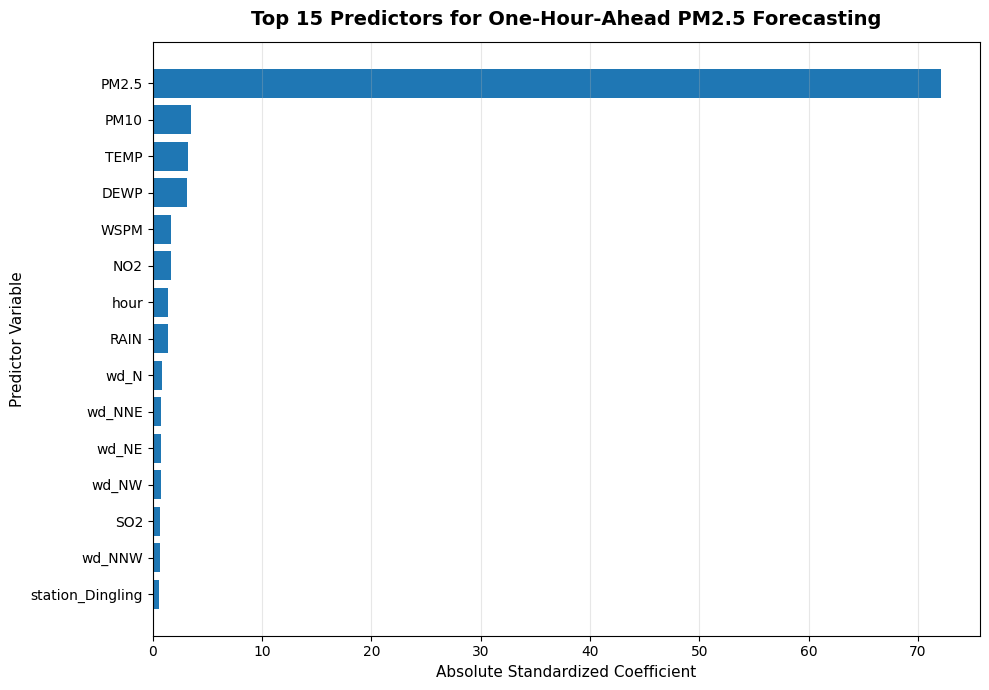

In [59]:
# ============================================================
# Top 15 Feature Importance Plot - Linear Regression
# ============================================================

import matplotlib.pyplot as plt                             # Import plotting library

# Sort features so the most important appears at the top
plot_data = top_features.sort_values(                       # Sort DataFrame by importance
    by='Absolute Standardized Coefficient',                 # Use absolute standardized coefficient
    ascending=True                                          # Ascending so most important ends up at top in barh
)

# Create horizontal bar chart
plt.figure(figsize=(10, 7))                                 # Set figure size (width=10, height=7)

plt.barh(                                                   # Horizontal bar chart
    plot_data['Feature'],                                   # Y-axis: feature names
    plot_data['Absolute Standardized Coefficient']          # X-axis: importance values
)

# Add chart title
plt.title(
    'Top 15 Predictors for One-Hour-Ahead PM2.5 Forecasting', # Title text
    fontsize=14,                                           # Title font size
    fontweight='bold',                                     # Bold title
    pad=12                                                 # Padding above title
)

# Add axis labels
plt.xlabel(
    'Absolute Standardized Coefficient',                   # X-axis label
    fontsize=11                                            # Font size
)

plt.ylabel(
    'Predictor Variable',                                  # Y-axis label
    fontsize=11                                            # Font size
)

# Add light gridlines for readability
plt.grid(
    axis='x',                                              # Gridlines along x-axis
    alpha=0.3                                              # Transparency
)

# Optimize layout
plt.tight_layout()                                         # Adjust spacing for readability

# Display plot
plt.show()                                                 # Render chart


### **Interpretation:**

#### **Feature Influence in the Linear Regression Model**

* The feature-importance plot presents the **top 15 predictors based on the absolute standardized coefficients** of the Linear Regression model. Using standardized coefficients allows the relative predictive influence of variables measured on different scales to be compared.

* **Current-hour PM2.5 is overwhelmingly the most influential predictor**, with an absolute standardized coefficient of approximately **72.06**, substantially exceeding all other variables.

* **PM10 (3.46)** is the second most influential predictor, followed by **TEMP (3.24)** and **DEWP (3.17)**.

* **WSPM (1.67), NO2 (1.64), hour (1.39), and RAIN (1.38)** show smaller but noticeable contributions to the one-hour-ahead forecast.

* Wind-direction indicators, **SO2**, and the **Dingling station indicator** have comparatively smaller standardized coefficients, suggesting more limited contributions within the Linear Regression model.

### **Overall Observation**

* The feature analysis demonstrates that **current-hour PM2.5 is the dominant source of predictive information for one-hour-ahead forecasting**.

* This finding is consistent with the strong correlation of **0.9683** previously observed between current-hour and one-hour-ahead PM2.5, indicating substantial short-term persistence in PM2.5 concentrations.

* Although meteorological, pollutant, temporal, wind-direction, and station variables contribute additional predictive information, their individual influence is considerably smaller than that of current-hour PM2.5.

> **Note:** The plot uses **absolute standardized coefficients** and therefore represents the **magnitude of predictive influence**, rather than the direction of the relationship. Positive and negative relationships are identified from the signed standardized coefficients presented in the preceding table.

## **6.9 SHAP Analysis - Linear Regression**

* **SHAP (SHapley Additive exPlanations)** analysis was performed on the **Linear Regression model** to provide additional interpretability for the one-hour-ahead PM2.5 forecasts. While the standardized coefficient analysis identifies the relative strength and direction of the predictors at the global model level, SHAP analysis provides a complementary explanation of how individual predictor values contribute to the model's predictions.

* A representative sample of the **chronological testing dataset** was used for the SHAP analysis to improve computational efficiency while ensuring that the explanations were based on observations from the unseen testing period.

* The **SHAP summary plot** was used to identify the predictors with the greatest overall influence on the model's forecasts and to examine whether higher or lower feature values tended to increase or decrease the predicted **next-hour PM2.5 concentration**.

* This analysis complements the standardized coefficient analysis by providing an additional model-interpretability perspective on the factors influencing the **one-hour-ahead PM2.5 forecasts**.

### **6.9.1 SHAP Analysis Setup**

In [60]:
# ============================================================
# 6.9.1 SHAP Analysis Setup
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Select representative observations from the chronological
# testing dataset
# ------------------------------------------------------------

X_shap = X_test.sample(
    n=min(5000, len(X_test)),       # Use up to 5,000 unseen test observations
    random_state=42                 # Fixed seed for reproducibility
)

# ------------------------------------------------------------
# Select background observations from the training dataset
# ------------------------------------------------------------

X_background = X_train.sample(
    n=min(100, len(X_train)),      # Use up to 100 training observations
    random_state=42                 # Fixed seed for reproducibility
)

# ------------------------------------------------------------
# Create SHAP explainer for the trained Linear Regression model
# ------------------------------------------------------------

explainer = shap.LinearExplainer(
    lr_model,                       # Trained Linear Regression model
    X_background                    # Background training observations
)

# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

shap_values = explainer(
    X_shap
)

# ------------------------------------------------------------
# Display analysis information
# ------------------------------------------------------------

print("=" * 70)
print("SHAP ANALYSIS - LINEAR REGRESSION")
print("=" * 70)

print(
    "Observations used for SHAP analysis:",
    len(X_shap)
)

print(
    "Background observations:",
    len(X_background)
)

print(
    "Number of predictor variables:",
    X_shap.shape[1]
)

print(
    "SHAP values shape:",
    shap_values.values.shape
)

SHAP ANALYSIS - LINEAR REGRESSION
Observations used for SHAP analysis: 5000
Background observations: 100
Number of predictor variables: 41
SHAP values shape: (5000, 41)


### **Interpretation:**

* SHAP analysis was performed using a sample of **5,000 observations**, with **100 background observations** used to support the calculation of SHAP values.

* The analysis included all **41 predictor variables** used by the final **Linear Regression model**.

* The resulting SHAP values had a shape of **(5,000, 41)**, confirming that a SHAP value was generated for each predictor variable across all sampled observations.


### **6.9.2 SHAP Summary Plot**

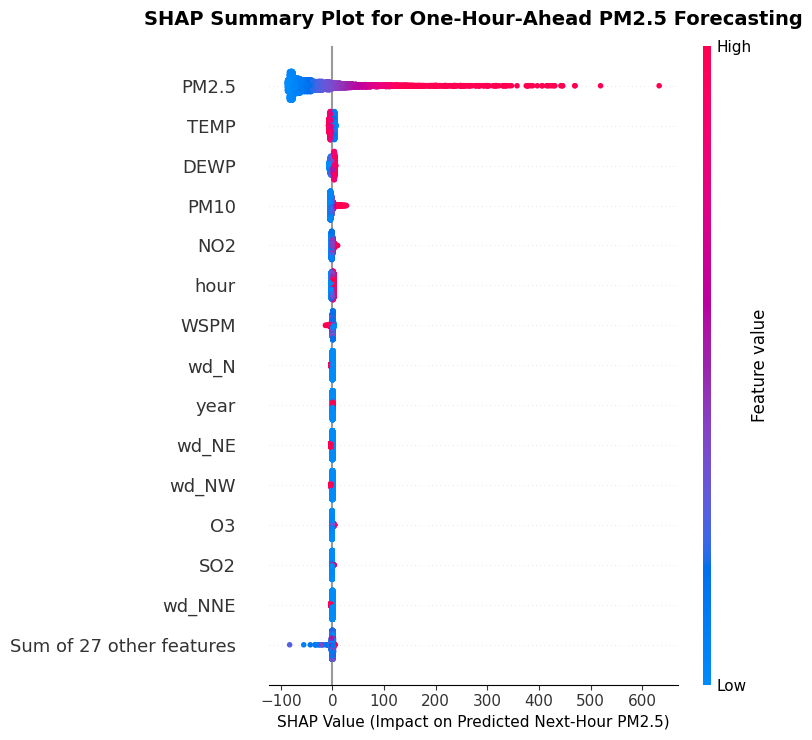

In [61]:
# ============================================================
# SHAP Summary Plot - Linear Regression
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Convert SHAP feature values to numeric format for plotting
# ------------------------------------------------------------

X_shap_numeric = X_shap.astype(float)

# Create a clean SHAP Explanation object
shap_explanation = shap.Explanation(
    values=np.asarray(shap_values.values, dtype=float),
    base_values=np.asarray(shap_values.base_values, dtype=float),
    data=X_shap_numeric.to_numpy(dtype=float),
    feature_names=X_shap_numeric.columns.tolist()
)

# ------------------------------------------------------------
# Create SHAP beeswarm summary plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

shap.plots.beeswarm(
    shap_explanation,
    max_display=15,
    show=False
)

# Add customized title
plt.title(
    'SHAP Summary Plot for One-Hour-Ahead PM2.5 Forecasting',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# Add clear x-axis label
plt.xlabel(
    'SHAP Value (Impact on Predicted Next-Hour PM2.5)',
    fontsize=11
)

plt.tight_layout()

# Display plot
plt.show()

### **Interpretation:**

#### **SHAP Summary Plot**

* The SHAP summary plot illustrates the **magnitude and direction of each predictor's contribution** to the Linear Regression model's one-hour-ahead PM2.5 predictions.

* **Current-hour PM2.5 is clearly the dominant predictor**, showing a substantially wider range of SHAP values than all other variables.

* Higher current-hour **PM2.5 values** generally produce large **positive SHAP values**, increasing the predicted next-hour PM2.5 concentration, while lower current-hour values contribute toward lower predictions.

* **TEMP, DEWP, PM10, NO2, hour, and WSPM** also contribute to the predictions, although their SHAP-value ranges are considerably smaller than that of current-hour PM2.5.

* The remaining predictors, including wind-direction indicators, **year, O3, and SO2**, show relatively smaller individual contributions to the model predictions.

* The **“Sum of 27 other features”** represents the combined contribution of the remaining predictors not displayed individually in the summary plot.

### **Overall Observation**

* The SHAP summary plot confirms that **current-hour PM2.5 is the primary driver of the model's one-hour-ahead forecasts**, demonstrating strong short-term persistence in PM2.5 concentrations.

* Other pollutant, meteorological, temporal, wind-direction, and station-related variables provide additional predictive information, but their individual influence is substantially smaller than that of current-hour PM2.5.

* Overall, the SHAP analysis supports the earlier feature analysis and provides additional interpretability regarding how the predictor variables contribute to the final Linear Regression model's forecasts.


### **6.9.3 SHAP Feature Importance**

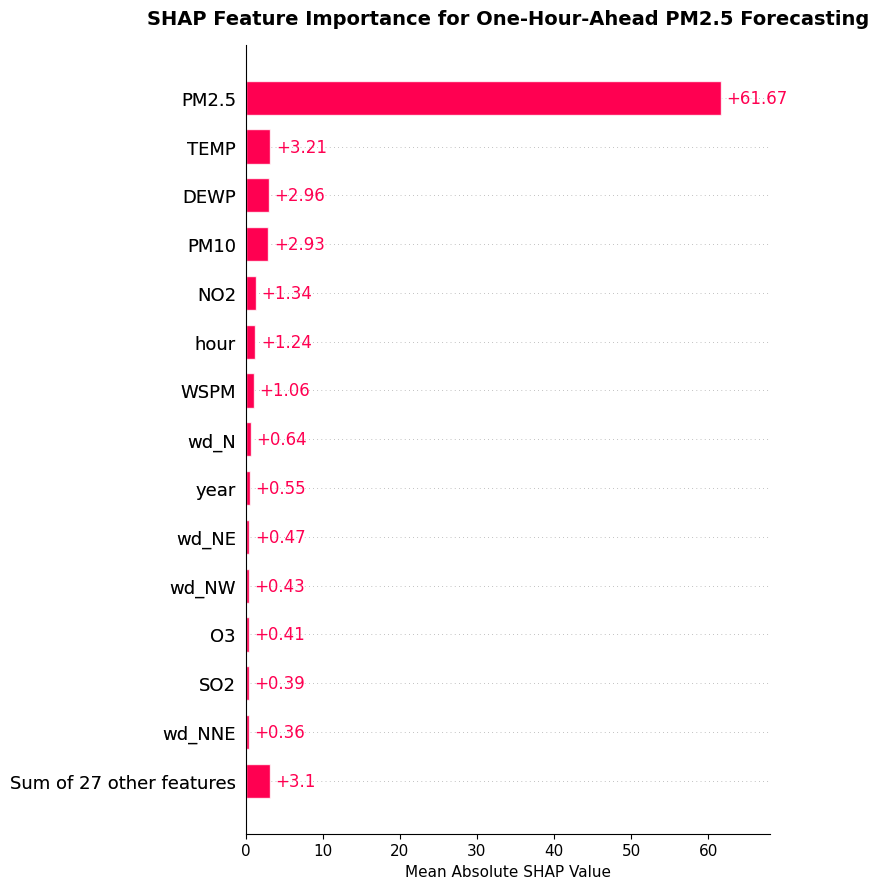

In [62]:
# ============================================================
# SHAP Feature Importance Bar Plot - Linear Regression
# ============================================================

import shap
import matplotlib.pyplot as plt

# Create SHAP feature importance bar plot
# Importance is based on mean absolute SHAP values
shap.plots.bar(
    shap_explanation,
    max_display=15,
    show=False
)

# Add customized title
plt.title(
    'SHAP Feature Importance for One-Hour-Ahead PM2.5 Forecasting',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# Add clear x-axis label
plt.xlabel(
    'Mean Absolute SHAP Value',
    fontsize=11
)

# Improve plot spacing
plt.tight_layout()

# Display plot
plt.show()

### **Interpretation:**

#### **SHAP Feature Importance**

* The SHAP feature-importance plot ranks the predictor variables according to their **mean absolute SHAP values**, representing the average magnitude of each feature's contribution to the model predictions.

* **Current-hour PM2.5 is by far the most influential predictor**, with a mean absolute SHAP value of **61.67**, substantially higher than all other individual predictors.

* **TEMP (3.21), DEWP (2.96), and PM10 (2.93)** are the next most influential predictors, although their contributions are considerably smaller than that of current-hour PM2.5.

* **NO2 (1.34), hour (1.24), and WSPM (1.06)** also contribute to the one-hour-ahead PM2.5 forecasts, but with relatively lower importance.

* Wind-direction variables, **year, O3, and SO2** show comparatively smaller individual contributions to the model predictions.

* The **remaining 27 predictors collectively contribute a mean absolute SHAP value of approximately 3.10**, indicating that their combined contribution is present but relatively small compared with current-hour PM2.5.

### **Overall Observation**

* The SHAP feature-importance analysis confirms that **current-hour PM2.5 is the dominant predictor of one-hour-ahead PM2.5 concentration**.

* While meteorological, pollutant, temporal, wind-direction, and other variables provide additional predictive information, their contributions are substantially smaller than that of current-hour PM2.5.

* These findings are consistent with the earlier feature analysis and further support the importance of **short-term persistence in PM2.5 concentrations** for one-hour-ahead forecasting.

> **Note:** Mean absolute SHAP values represent the **magnitude of feature contributions** to model predictions and do not indicate the direction of the relationship or establish causal effects.


## **6.10 Final Model Evaluation**

* Based on the comparative evaluation of the machine learning models, **Linear Regression emerged as the best-performing model** for one-hour-ahead PM2.5 forecasting based on the chronological testing results.

* On the **chronological training dataset**, Linear Regression achieved an **MAE of 10.81 µg/m³**, **RMSE of 20.06 µg/m³**, and **R² of 0.9382**. On the unseen **chronological testing dataset**, the model achieved an **MAE of 10.16 µg/m³**, **RMSE of 19.13 µg/m³**, and **R² of 0.9477**.

* The similarity between the training and testing performance indicates that the model maintained strong predictive performance on unseen future observations without evidence of substantial overfitting. The slightly stronger testing performance may reflect differences in pollution patterns and forecasting difficulty between the training and testing periods.

* The robustness of the selected model was further assessed using **5-fold expanding-window time-series cross-validation**. Across the five chronological validation folds, the model achieved a **mean MAE of 11.94 µg/m³**, **mean RMSE of 20.43 µg/m³**, and **mean R² of 0.9320**.

* The R² values across the five validation folds ranged from **0.9126 to 0.9468**, with an **R² standard deviation of 0.0138**. This relatively low variation indicates that the model maintained consistent predictive performance across different temporal periods.

* Model interpretability analysis using **standardized coefficients and SHAP values** further demonstrated that **current-hour PM2.5 concentration was the dominant predictor of PM2.5 concentration one hour ahead**. The SHAP feature-importance analysis produced a mean absolute SHAP value of **61.67** for current-hour PM2.5, substantially higher than the contributions of the remaining individual predictors.

* Among the secondary predictors, **TEMP, DEWP, PM10, NO2, hour, and WSPM** contributed additional predictive information, although their individual influence was considerably smaller than that of current-hour PM2.5.

* Overall, the chronological test results, expanding-window cross-validation performance, and model interpretability analyses provide consistent evidence that **Linear Regression provides a robust and interpretable framework for one-hour-ahead PM2.5 forecasting using the available air pollution, meteorological, temporal, and location-related information**.

# **7. Results and Discussion**

The performance of eight machine learning models **Linear Regression, Decision Tree, Random Forest, XGBoost, Gradient Boosting, AdaBoost, LightGBM, and CatBoost** was evaluated for **one-hour-ahead PM2.5 forecasting**. Model performance was assessed using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²)** on a chronological testing dataset.

* **Linear Regression achieved the highest testing R² of 0.9477 and the lowest testing RMSE of 19.13 µg/m³**, with a testing MAE of **10.16 µg/m³**. These results indicate the strongest overall predictive performance based on R² and RMSE.

* **Gradient Boosting** achieved a testing **R² of 0.9458**, an **MAE of 9.91 µg/m³**, and an **RMSE of 19.48 µg/m³**, demonstrating performance close to that of Linear Regression.

* **LightGBM recorded the lowest testing MAE of 9.85 µg/m³**, together with an **RMSE of 19.60 µg/m³** and an **R² of 0.9452**. This indicates that LightGBM produced the smallest average absolute forecasting error, although Linear Regression achieved the highest R² and lowest RMSE.

* **XGBoost and CatBoost** also demonstrated strong predictive performance, achieving testing R² values of **0.9434** and **0.9432**, respectively.

* **Random Forest** achieved a testing **R² of 0.9394**, but its substantially stronger training performance (R² = **0.9924**) compared with testing performance indicates some degree of overfitting.

* **AdaBoost** and **Decision Tree** produced comparatively weaker testing performance, with R² values of **0.8665** and **0.8558**, respectively. The Decision Tree showed the clearest evidence of overfitting, achieving a training R² of **1.0000** but substantially lower performance on the unseen testing period.

### **Model Robustness and Interpretability**

* The selected **Linear Regression model** was further evaluated using **5-fold expanding-window time-series cross-validation**. The model achieved a **mean MAE of 11.94 µg/m³**, **mean RMSE of 20.43 µg/m³**, and **mean R² of 0.9320** across the five chronological validation folds.

* The validation R² values ranged from **0.9126 to 0.9468**, with a standard deviation of **0.0138**, indicating relatively consistent predictive performance across different temporal periods.

* Model interpretability analysis using **standardized coefficients and SHAP values** identified **current-hour PM2.5 concentration as the dominant predictor** of PM2.5 concentration one hour ahead.

* The SHAP feature-importance analysis showed a mean absolute SHAP value of **61.67** for current-hour PM2.5, substantially exceeding the contribution of the other individual predictors. **TEMP, DEWP, PM10, NO2, hour, and WSPM** provided additional predictive information, although their individual contributions were considerably smaller.

### **Overall Observation**

The results demonstrate that several models provided strong performance for **one-hour-ahead PM2.5 forecasting**, particularly Linear Regression, Gradient Boosting, LightGBM, XGBoost, and CatBoost. However, no single model achieved the best result across all three evaluation metrics.

**Linear Regression was selected as the final model because it achieved the highest testing R² (0.9477) and lowest testing RMSE (19.13 µg/m³), while LightGBM achieved the lowest testing MAE (9.85 µg/m³).**

The strong chronological testing performance, consistent time-series cross-validation results, and interpretable feature contributions support **Linear Regression as a robust and interpretable forecasting model** for predicting PM2.5 concentrations one hour ahead.

# **8. Conclusion**

This study developed and evaluated eight machine learning algorithms—**Linear Regression, Decision Tree, Random Forest, XGBoost, Gradient Boosting, AdaBoost, LightGBM, and CatBoost**—for **one-hour-ahead PM2.5 forecasting** using pollutant, meteorological, temporal, and location-related variables from the **Beijing Multi-Site Air Quality Dataset**.

Among the evaluated models, **Linear Regression emerged as the leading model overall**, achieving the **highest testing R² of 0.9477** and the **lowest testing RMSE of 19.13 µg/m³**, with an **MAE of 10.16 µg/m³** on the unseen chronological testing dataset. Although **LightGBM achieved the lowest testing MAE of 9.85 µg/m³**, Linear Regression was selected as the final forecasting model based on its combination of high explanatory performance, low RMSE, strong generalization, and interpretability.

The robustness of the selected model was further supported through **5-fold expanding-window time-series cross-validation**, where Linear Regression achieved a **mean MAE of 11.94 µg/m³**, **mean RMSE of 20.43 µg/m³**, and **mean R² of 0.9320**. The relatively low variation in R² across the validation folds further demonstrated consistent predictive performance across different temporal periods.

Model interpretability analysis using **standardized coefficients and SHAP values** identified **current-hour PM2.5 concentration as the dominant predictor of PM2.5 concentration one hour ahead**. Other variables, including **TEMP, DEWP, PM10, NO2, hour, and WSPM**, provided additional predictive information, although their individual contributions were considerably smaller.

Overall, the findings demonstrate that **one-hour-ahead PM2.5 concentrations can be forecast with strong predictive performance using current air-pollution, meteorological, temporal, and location-related information**. The results also demonstrate that a comparatively simple and interpretable model such as Linear Regression can perform competitively when strong short-term temporal persistence exists in PM2.5 concentrations.

The developed forecasting framework has the potential to support **short-term air-quality monitoring and forecasting applications** by providing timely estimates of future PM2.5 concentrations.

Future research may explore **longer forecasting horizons, additional lagged variables, deep learning and dedicated time-series models, traffic and land-use information, and real-time data integration** to further improve forecasting capability and assess the generalizability of the approach across different locations and environmental conditions.

## **8.1 Limitations**

* This study used the **Beijing Multi-Site Air Quality Dataset**, covering observations from **12 monitoring stations in Beijing between 2013 and 2017**. Therefore, the findings are specific to the geographical and temporal conditions represented in this dataset and may not directly generalize to other cities, regions, or time periods.

* The forecasting horizon was limited to **one hour ahead**. While this is useful for short-term forecasting, the performance of the developed models for longer forecasting horizons was not evaluated.

* The models were developed using the available **air pollutant, meteorological, temporal, wind-direction, and monitoring-station variables**. Other potentially relevant factors, such as traffic conditions, industrial activity, land-use characteristics, population density, and additional emission-related information, were not available in the dataset.

* The strong predictive performance of the final Linear Regression model was influenced substantially by **current-hour PM2.5**, which demonstrated a very strong relationship with one-hour-ahead PM2.5. Consequently, the forecasting performance may decrease as the prediction horizon increases and the influence of the most recent PM2.5 observation becomes weaker.

* Although **time-series cross-validation** was used to assess temporal robustness, the model was evaluated using historical observations from the same overall geographical region. Its performance on completely independent datasets or monitoring networks was not examined.




## **8.2 Future Research**

* Future studies may evaluate **longer forecasting horizons**, such as 3-hour, 6-hour, 12-hour, and 24-hour-ahead PM2.5 forecasting, to determine how predictive performance changes as the forecasting horizon increases.

* Additional **lagged and rolling-window features** may be incorporated to capture longer-term temporal patterns and recent trends in pollutant concentrations and meteorological conditions.

* Future research may investigate **dedicated time-series and deep learning approaches**, including models capable of learning more complex temporal dependencies, and compare their performance with the machine learning algorithms evaluated in this study.

* Additional predictors, including **traffic conditions, industrial emissions, land-use characteristics, population-related information, and other environmental variables**, may be incorporated to improve the representation of factors influencing PM2.5 concentrations.

* The forecasting framework may also be evaluated using **more recent datasets and data from other cities or geographical regions** to assess its external generalizability.

* Finally, future research may explore **real-time data integration and model deployment** to develop operational air-quality forecasting systems capable of providing timely PM2.5 predictions for monitoring and decision-support applications.